In [67]:
# Importing the libraries

import numpy as np
import pandas as pd
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
#importing dataset
dataset = pd.read_csv('/content/drive/MyDrive/Copy of CarPrice_project.csv')

#DATA INSPECTION


In [70]:
dataset.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [71]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [72]:
dataset.describe(include='all')

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
unique,NaN,NaN,147,2,2,2,5,3,2,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,peugeot 504,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,6,185,168,115,96,120,202,NaN,...,NaN,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,103.000000,0.834146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000


In [73]:
#duplicate
len(dataset[dataset.duplicated()])

0

In [74]:
dataset.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

# EDA

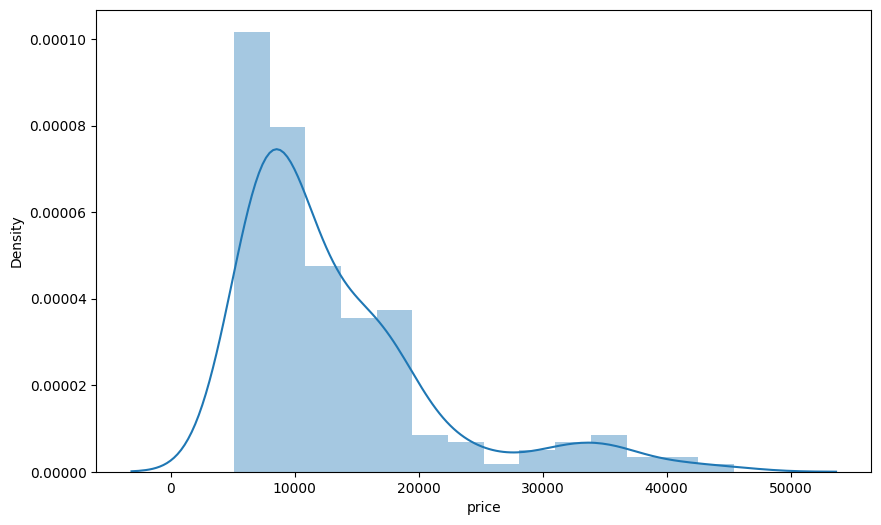

In [75]:
# dependent variable 'Price'

plt.figure(figsize=(10,6))
sns.distplot(dataset['price'])
plt.show()

#applying log transformation


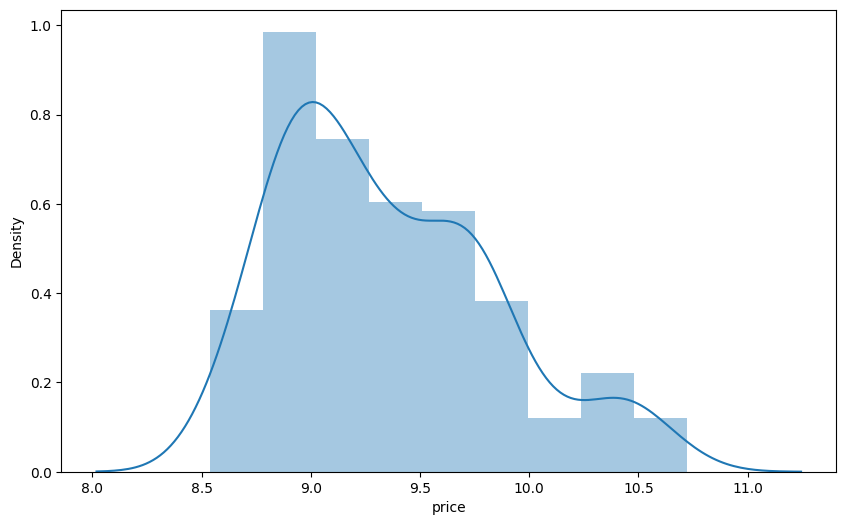

In [76]:
plt.figure(figsize=(10,6))
sns.distplot(np.log(dataset['price']))
plt.show()

In [77]:
numeric_features = dataset.describe().columns
numeric_features

Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

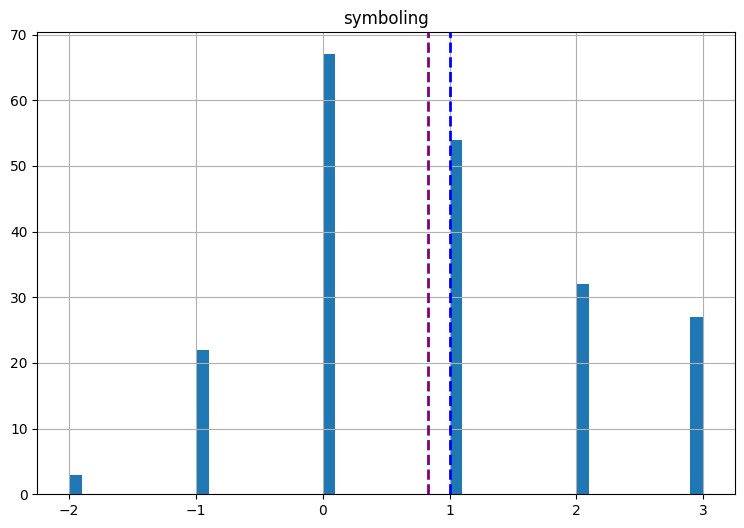

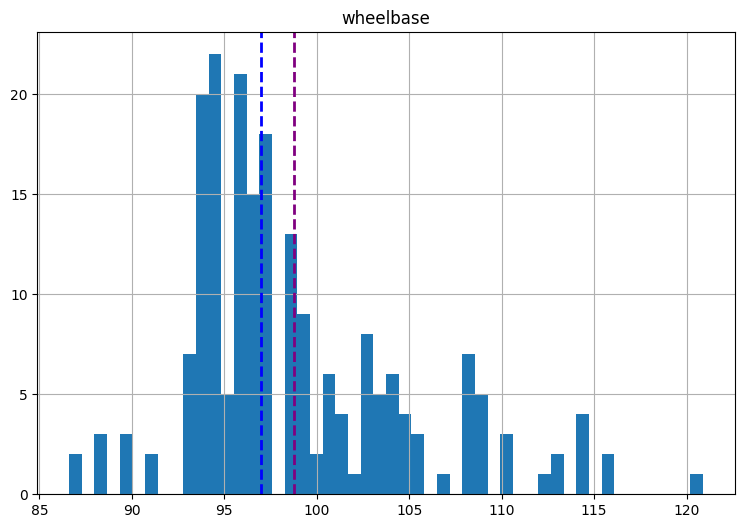

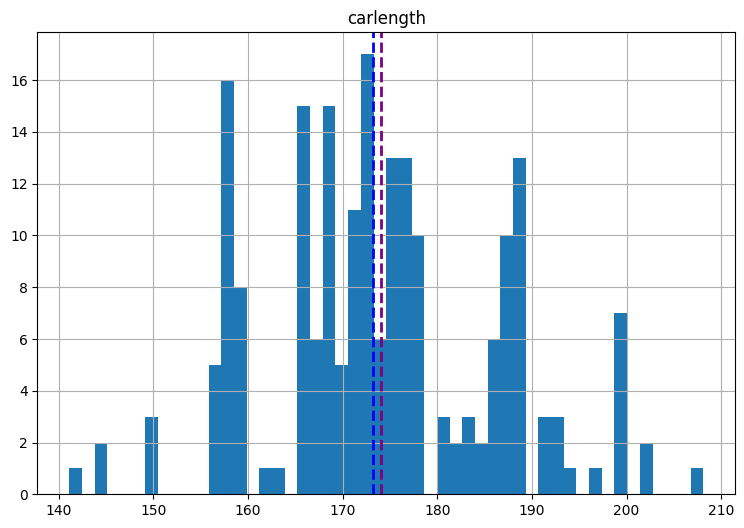

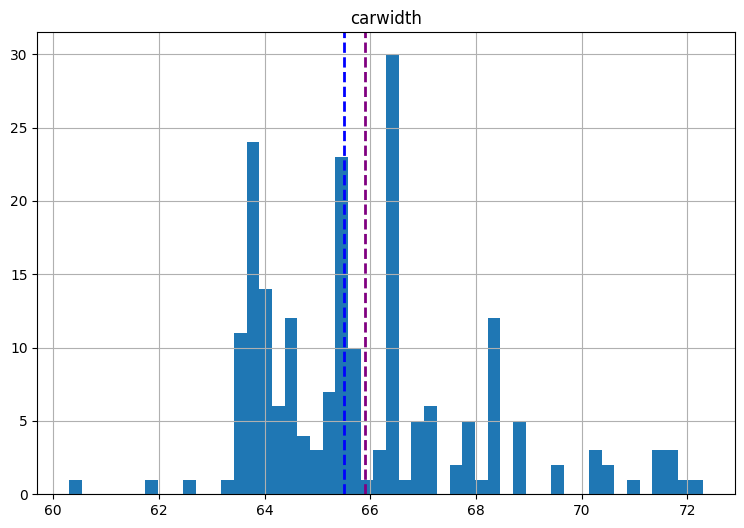

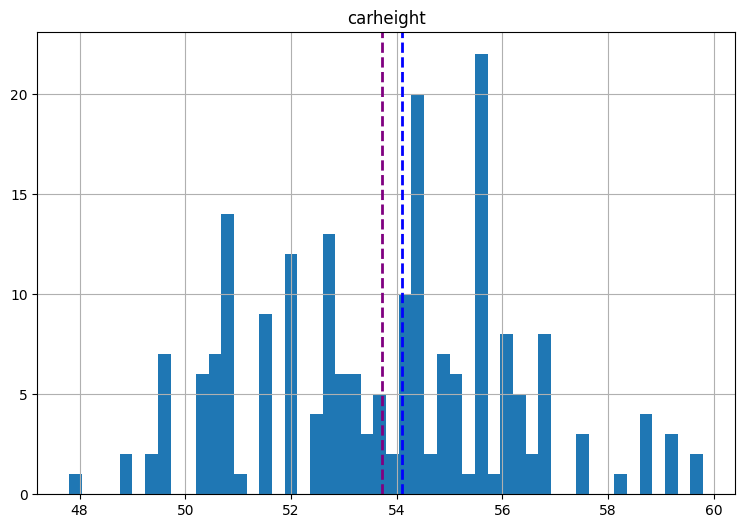

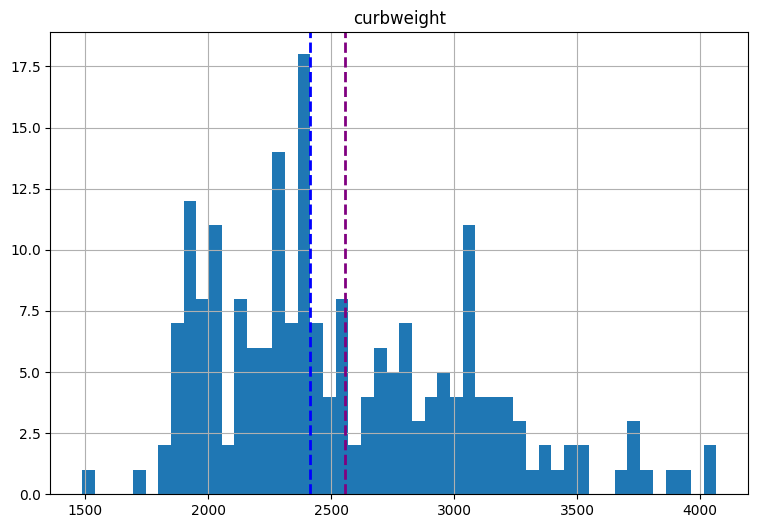

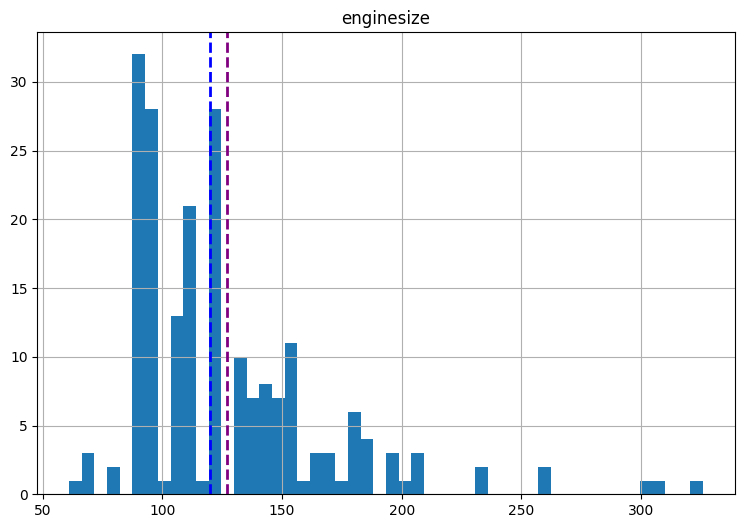

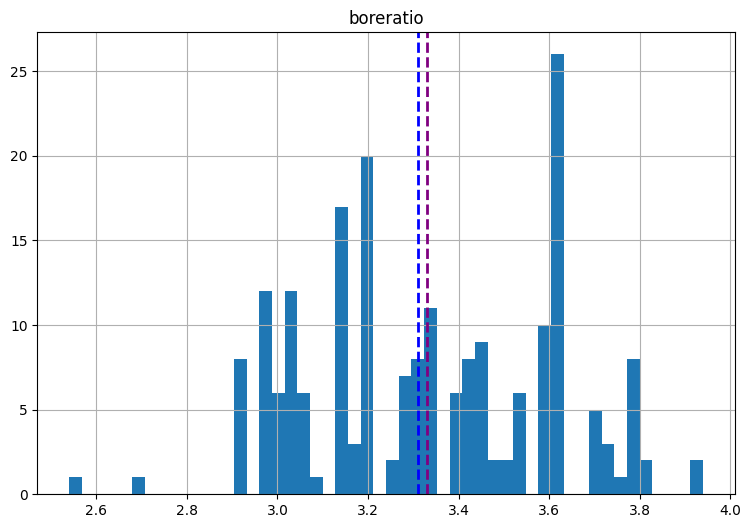

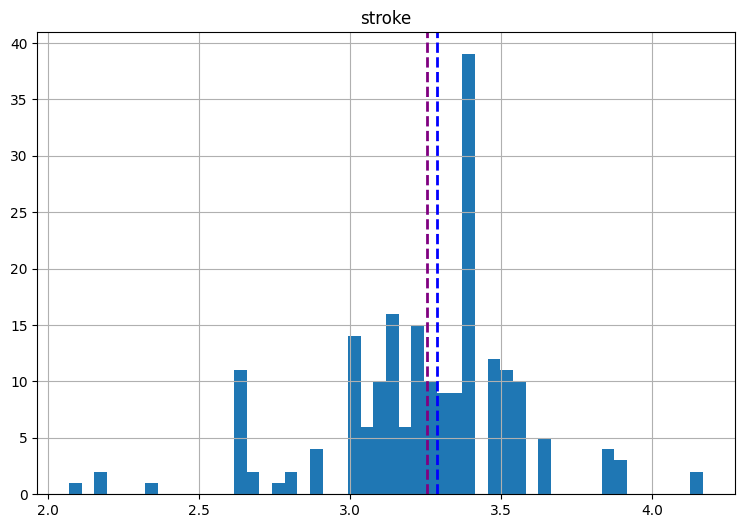

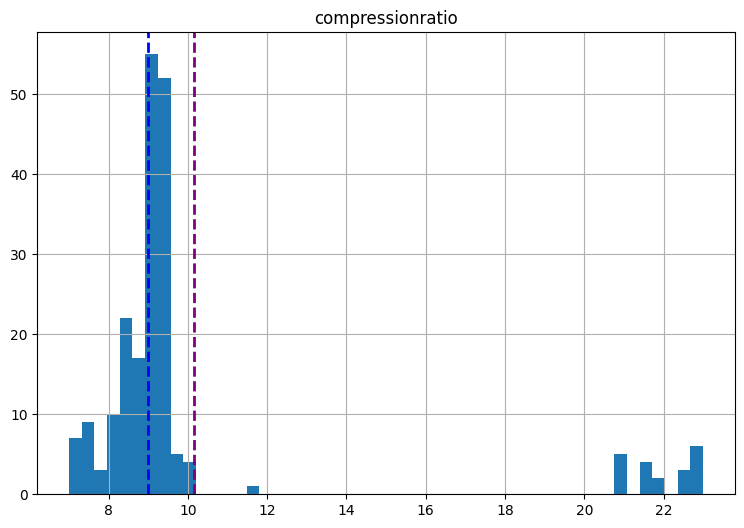

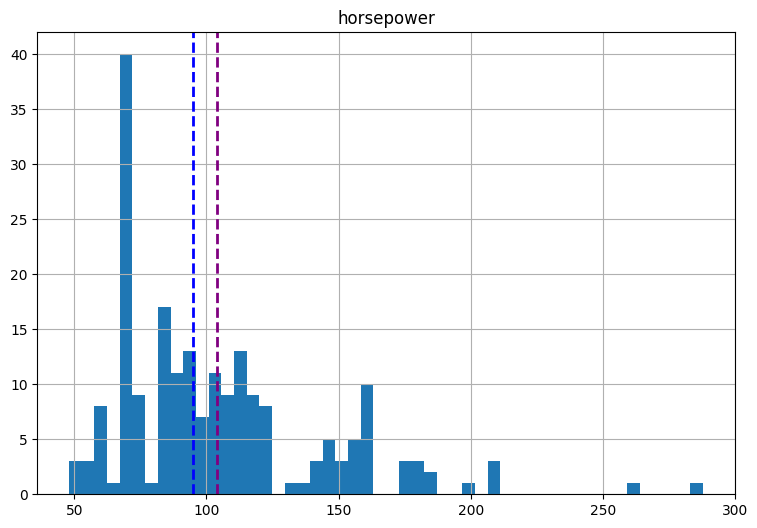

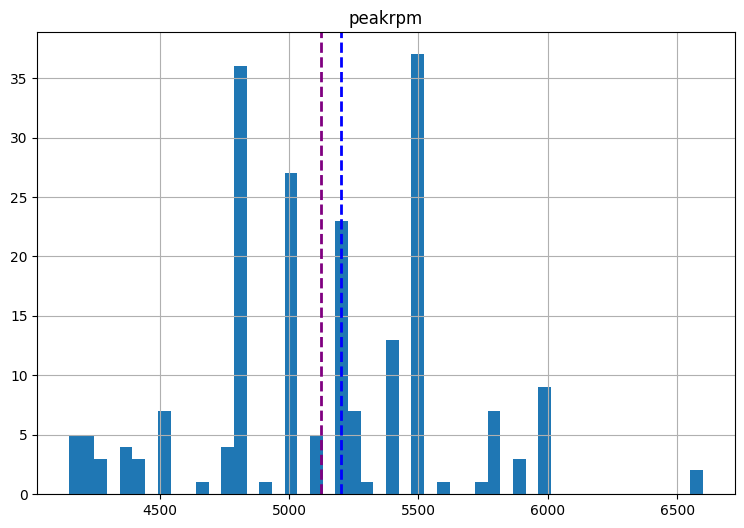

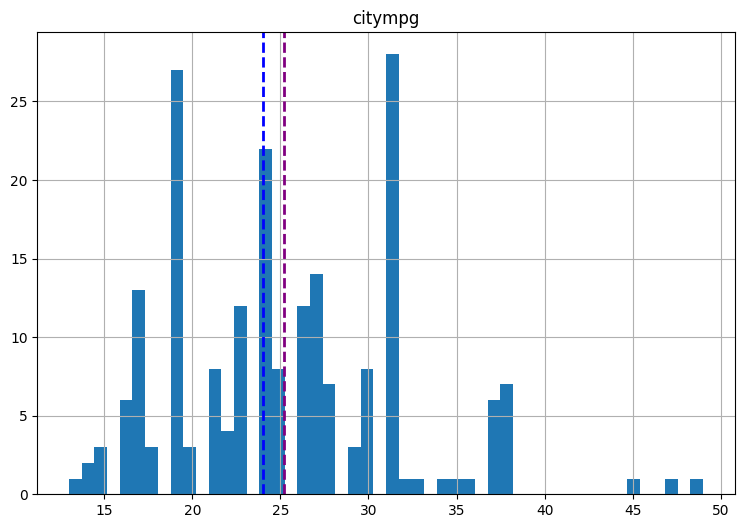

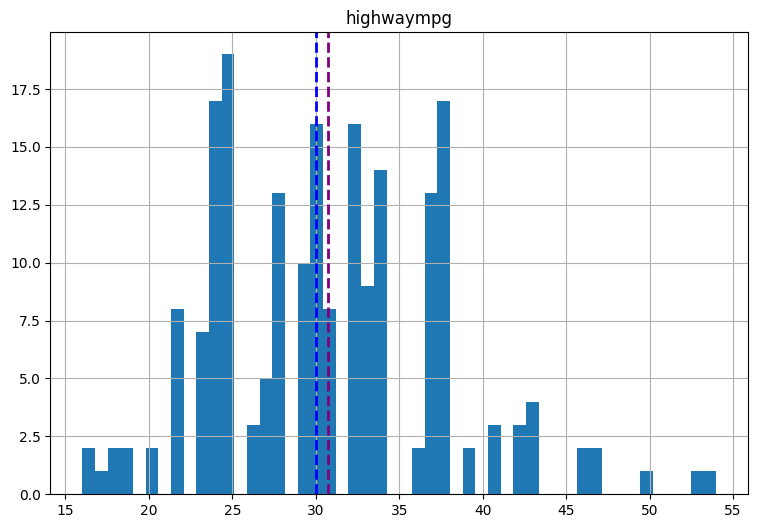

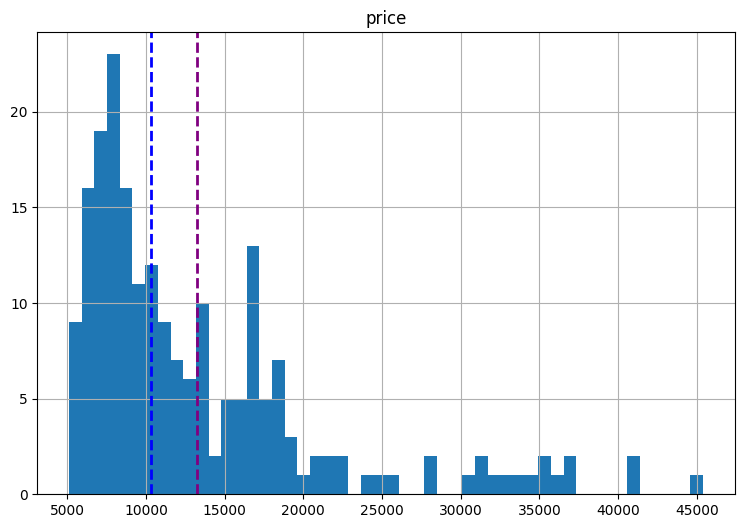

In [78]:
from matplotlib import axes
#plotting a bar plot for each numerical feature count( except car_id)

for col in numeric_features[1:]:
    fig= plt.figure(figsize=(9,6))
    ax = fig.gca()
    feature = dataset[col]
    feature.hist(bins=50, ax= ax)
    ax.axvline(feature.mean(), color = 'purple', linestyle= 'dashed',linewidth=2)
    ax.axvline(feature.median(), color = 'blue', linestyle= 'dashed',linewidth=2)
    ax.set_title(col)
plt.show()


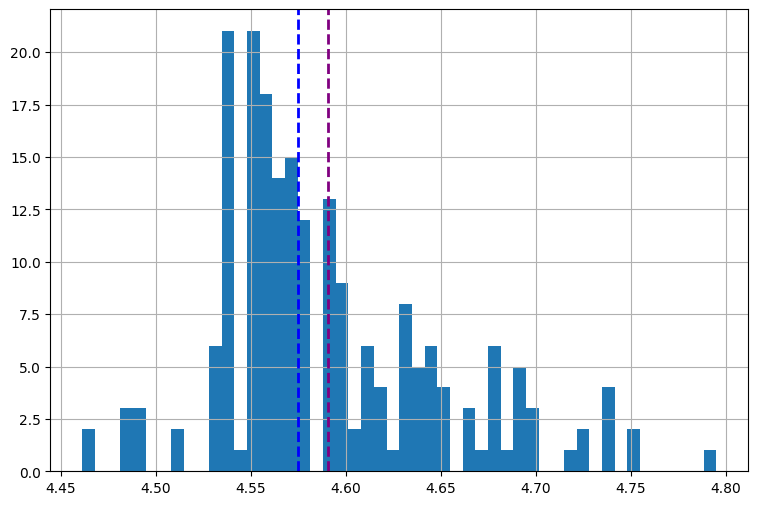

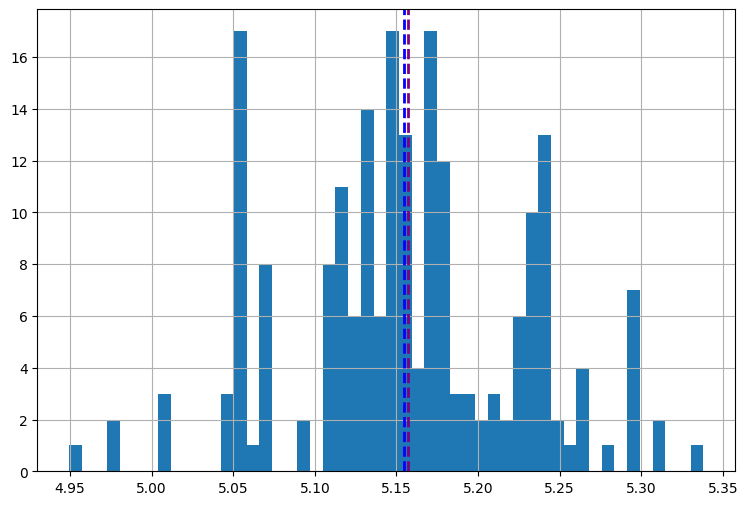

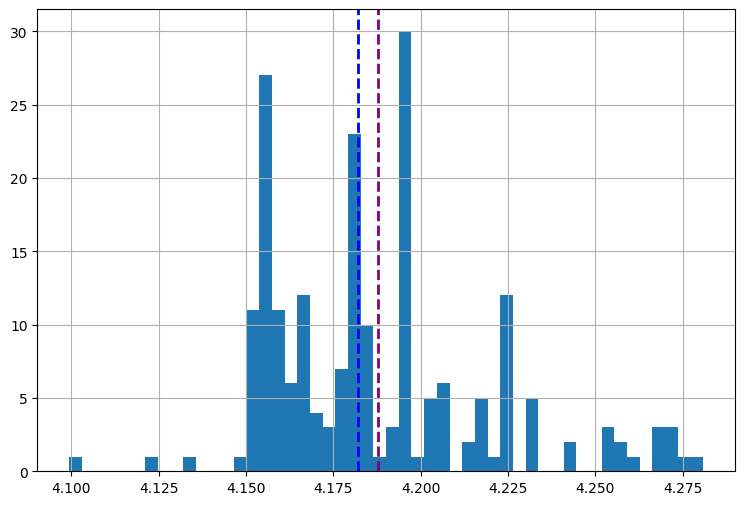

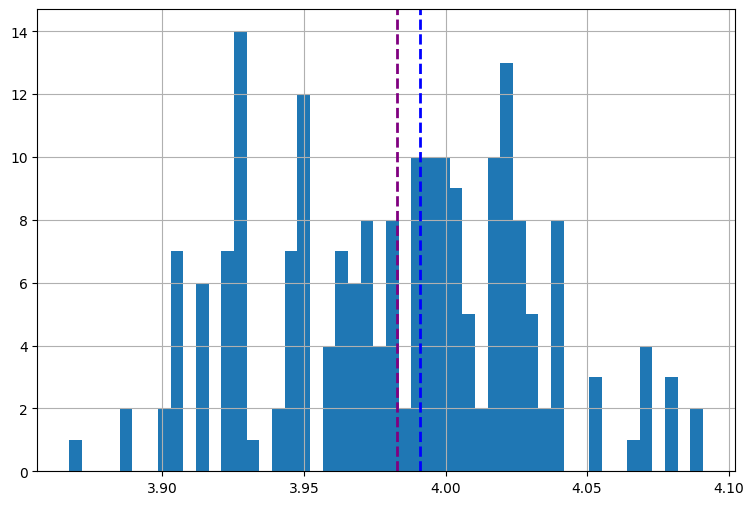

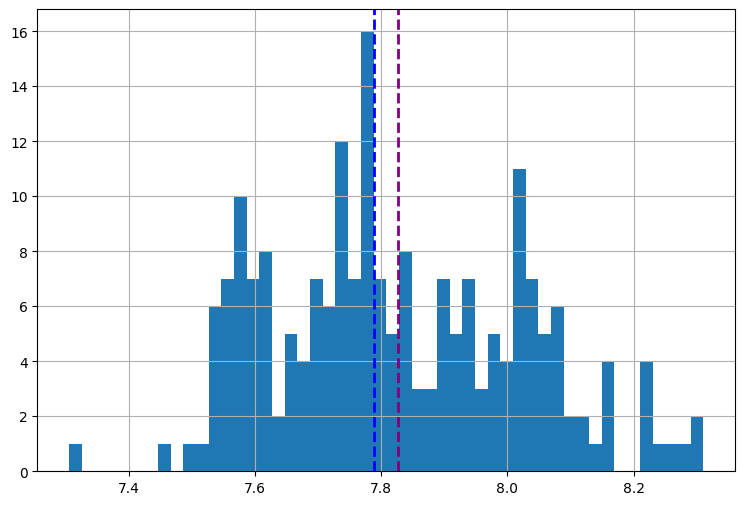

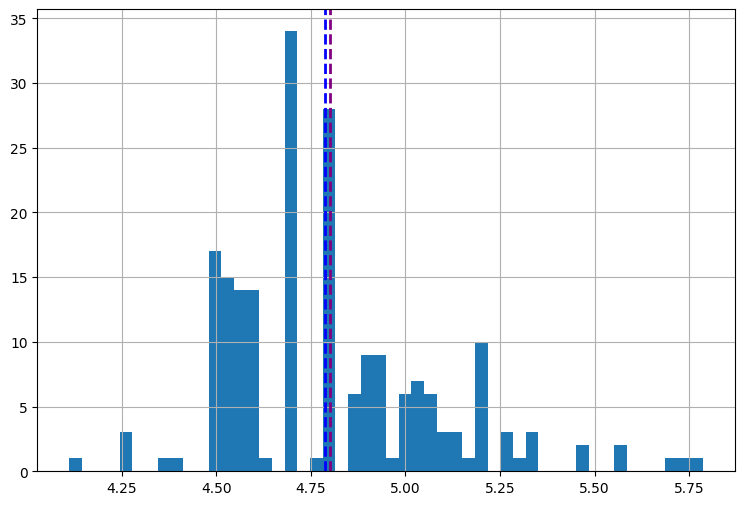

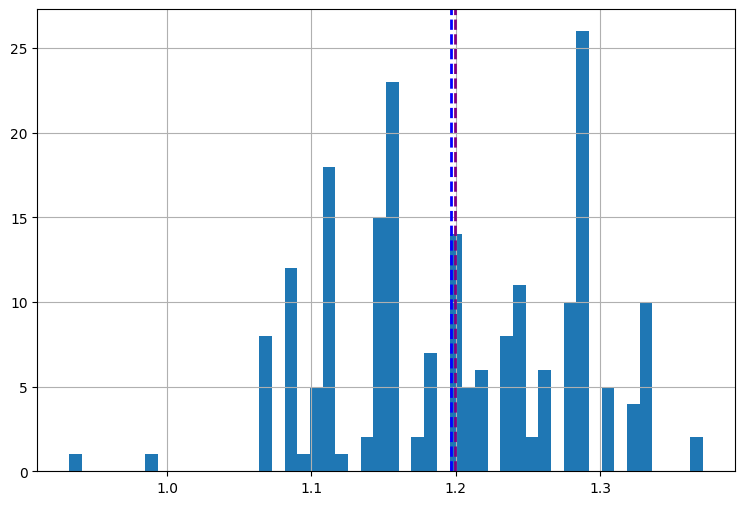

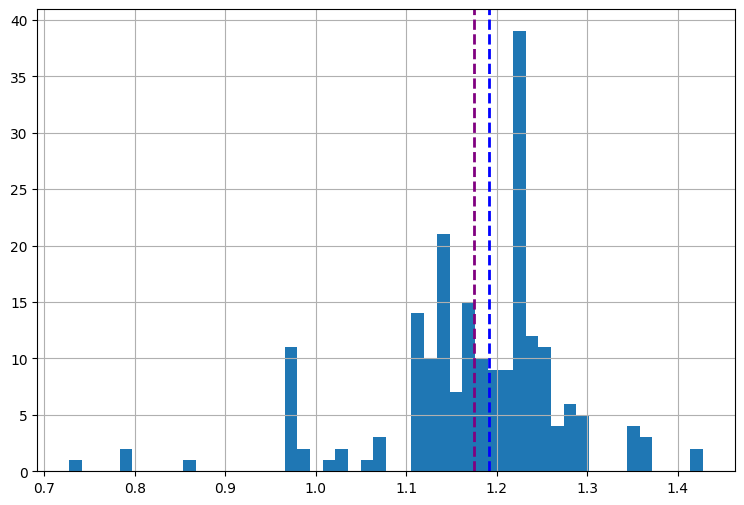

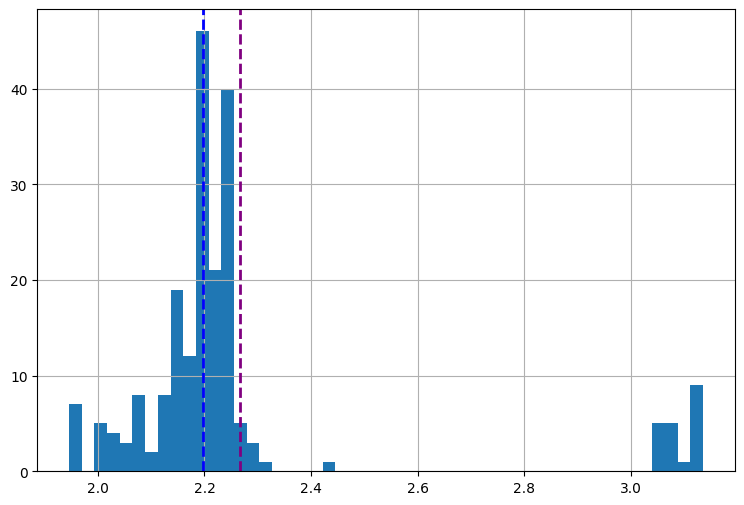

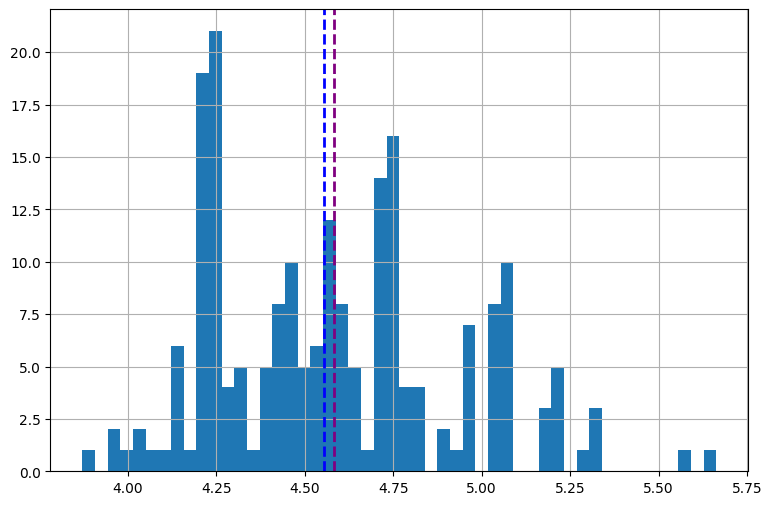

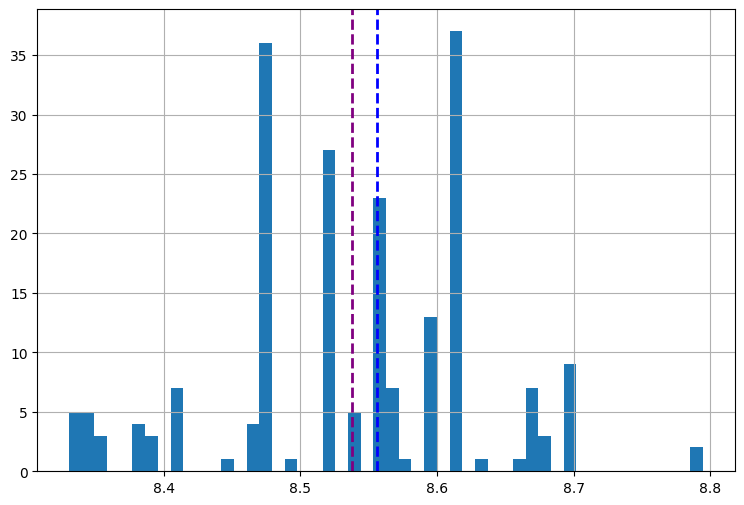

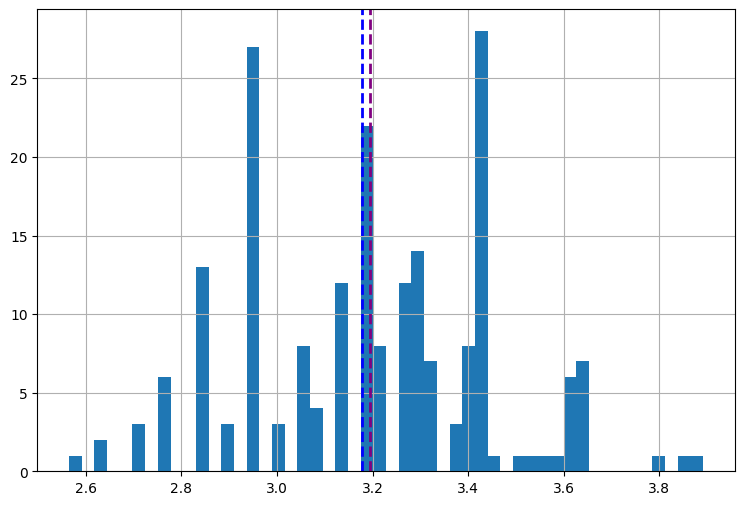

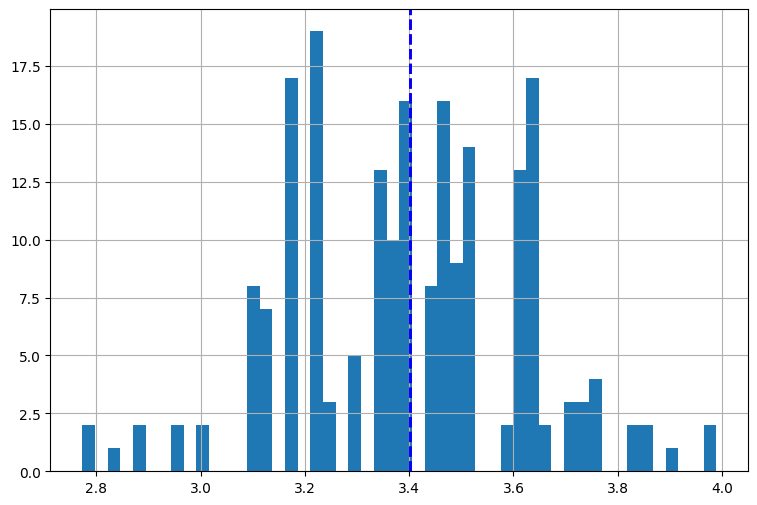

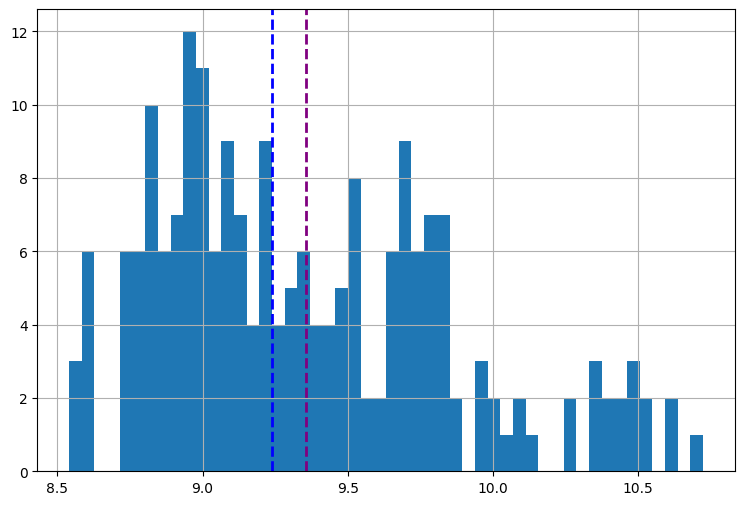

In [79]:
# removing skewness from each columns

for col in numeric_features[2:]:
    fig = plt.figure(figsize=(9,6))
    ax = fig.gca()
    feature = np.log(dataset[col])
    feature.hist(bins=50, ax=ax)
    ax.axvline(feature.mean(), color='purple', linestyle='dashed', linewidth=2)
    ax.axvline(feature.median(), color='blue', linestyle='dashed', linewidth=2)
    plt.show()
    plt.show()

# Determining Corelation btwn price and these columns


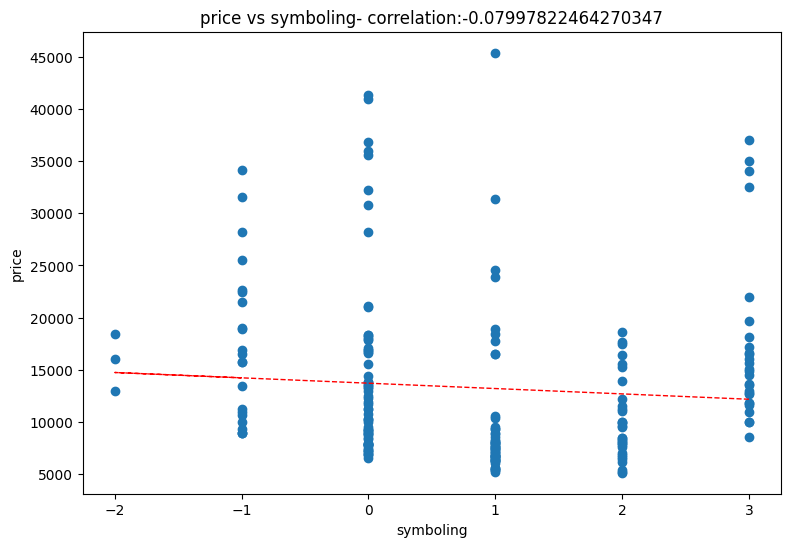

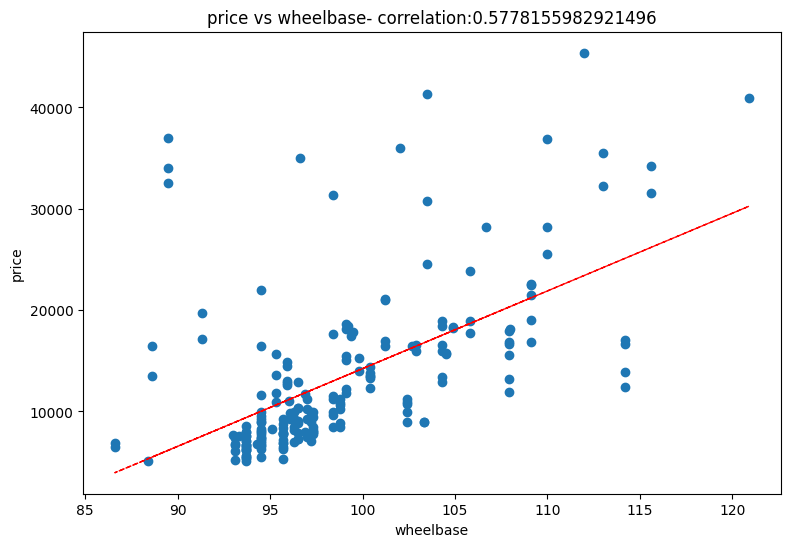

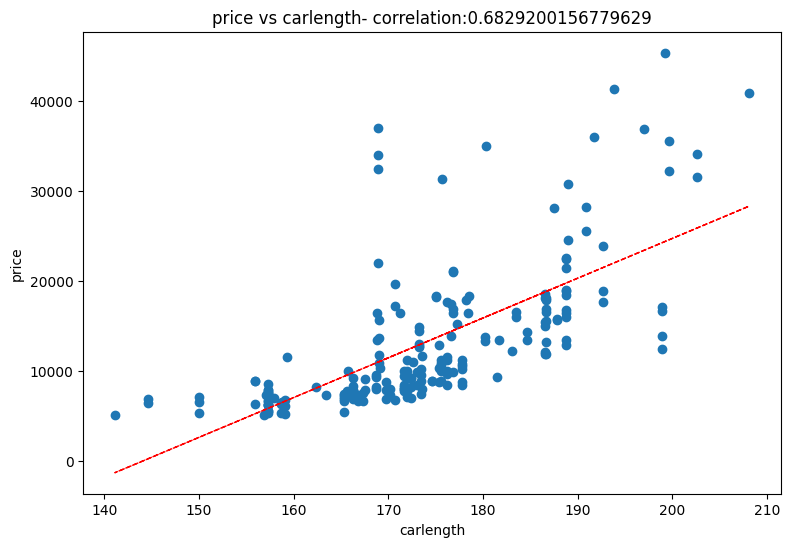

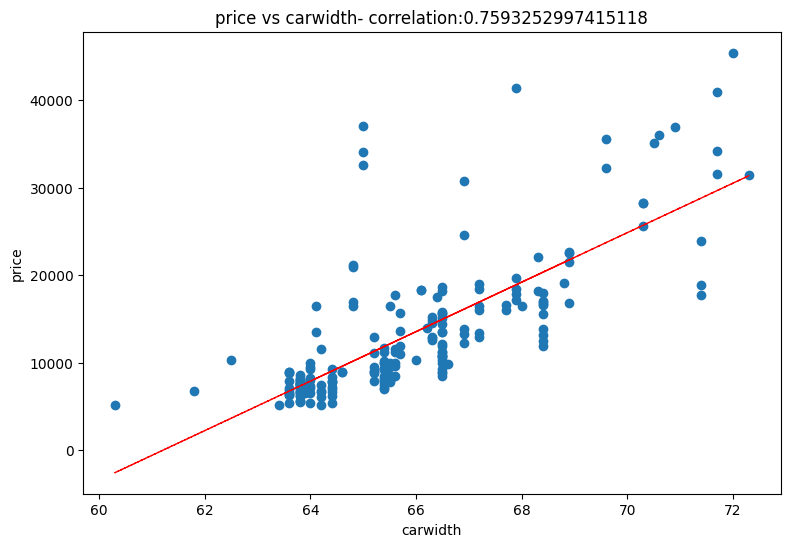

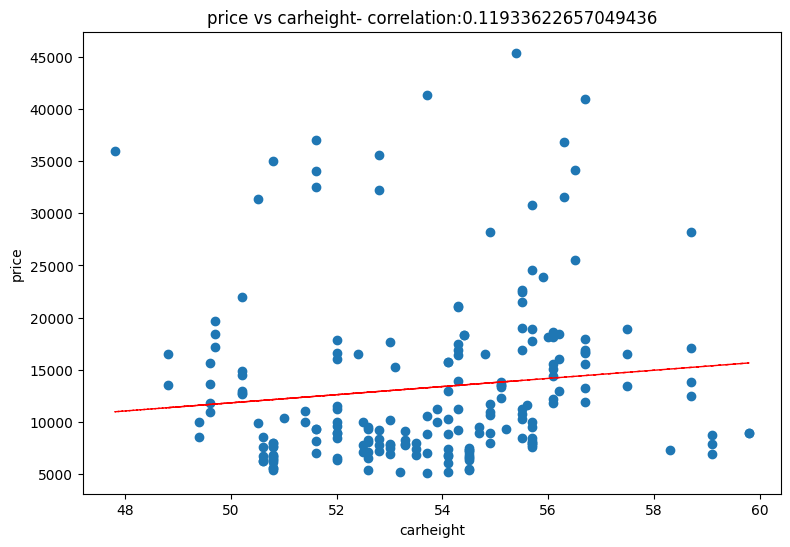

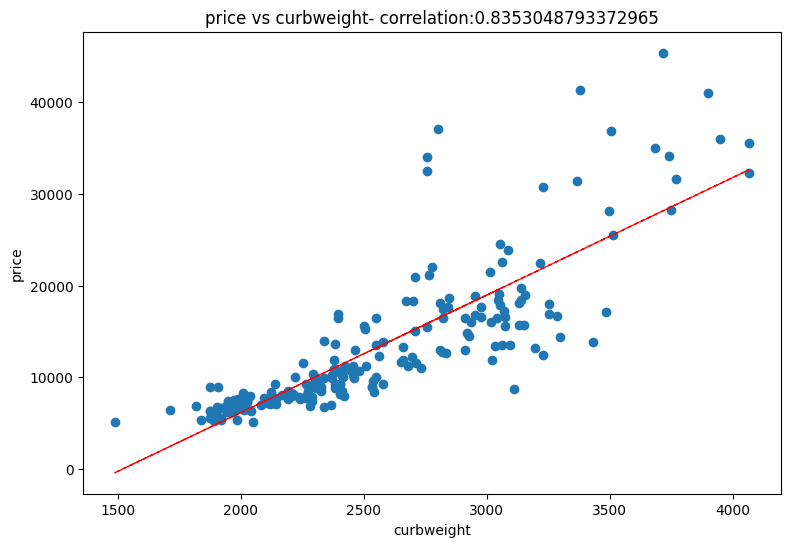

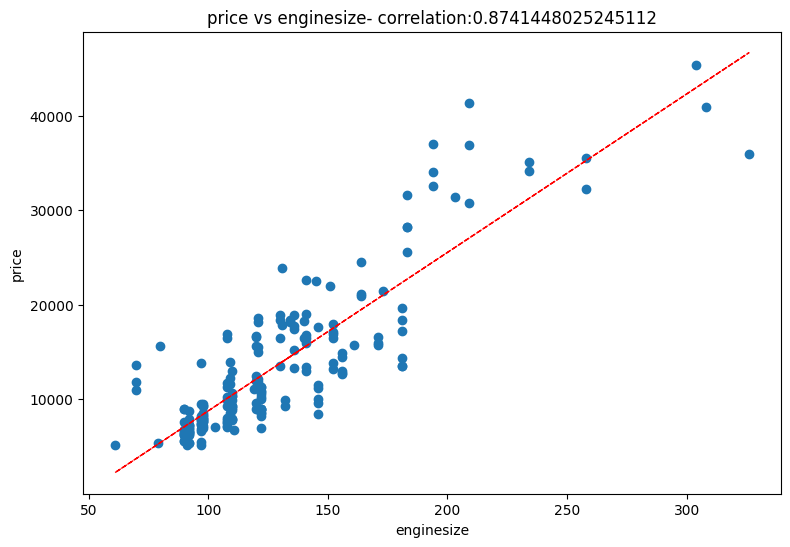

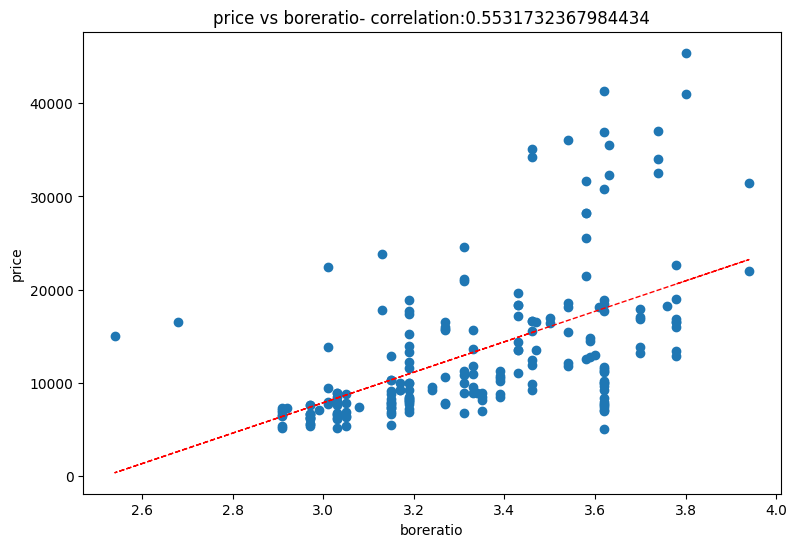

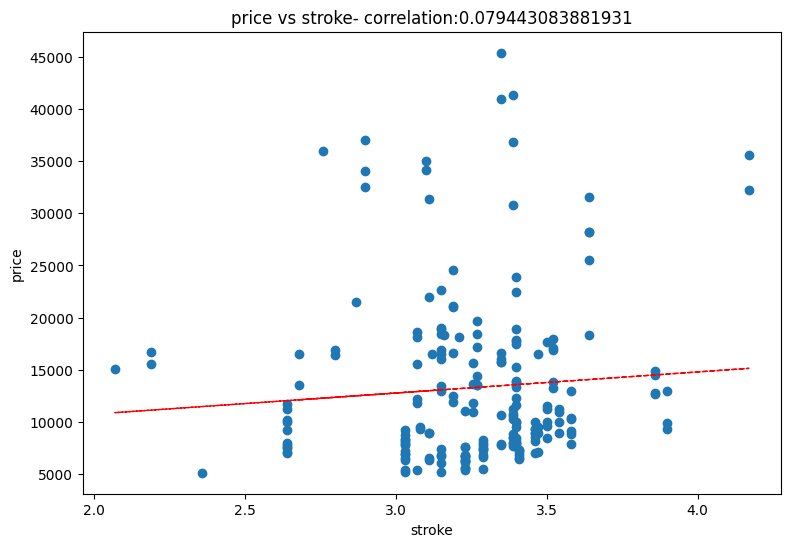

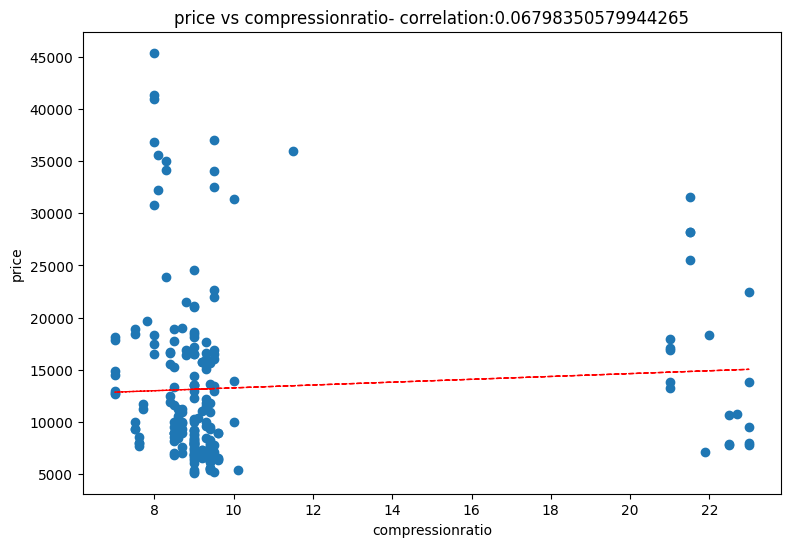

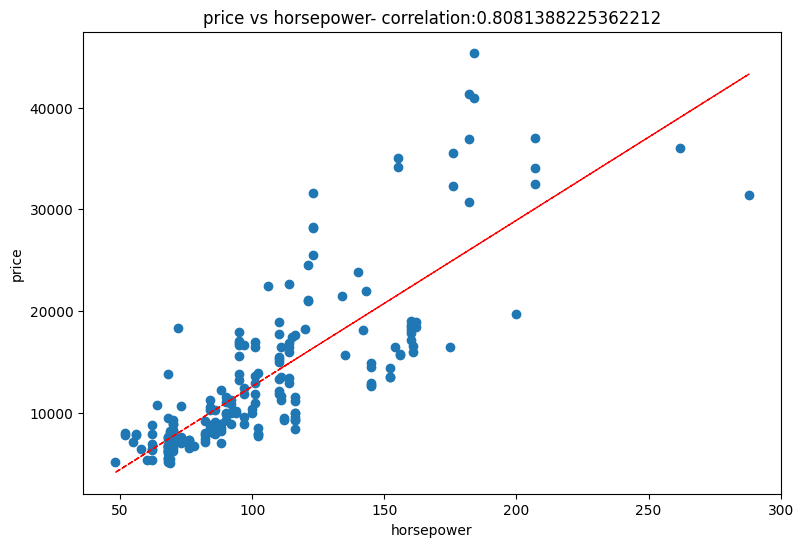

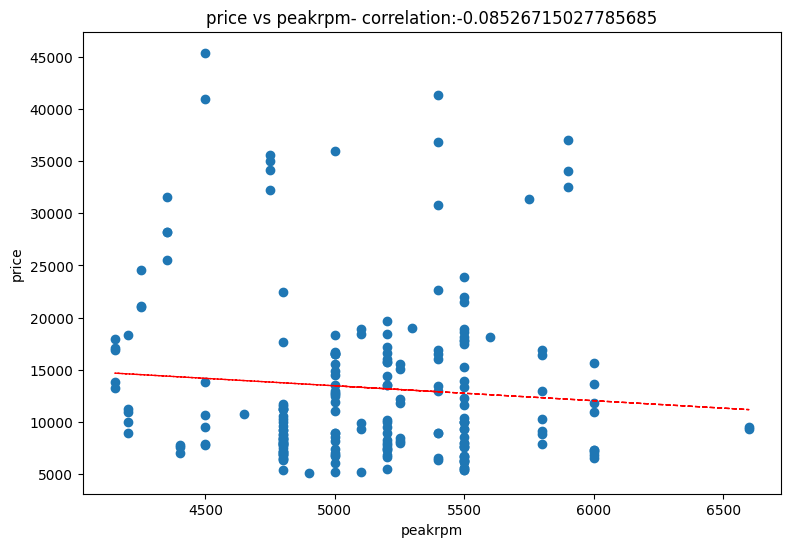

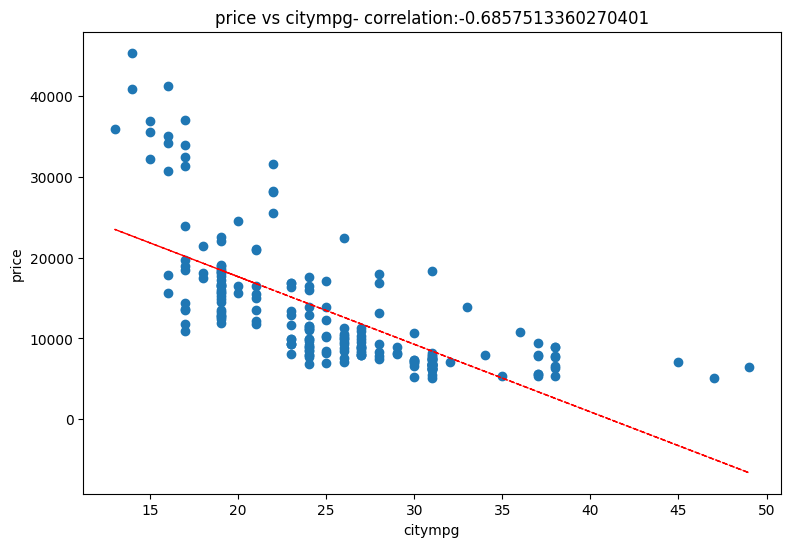

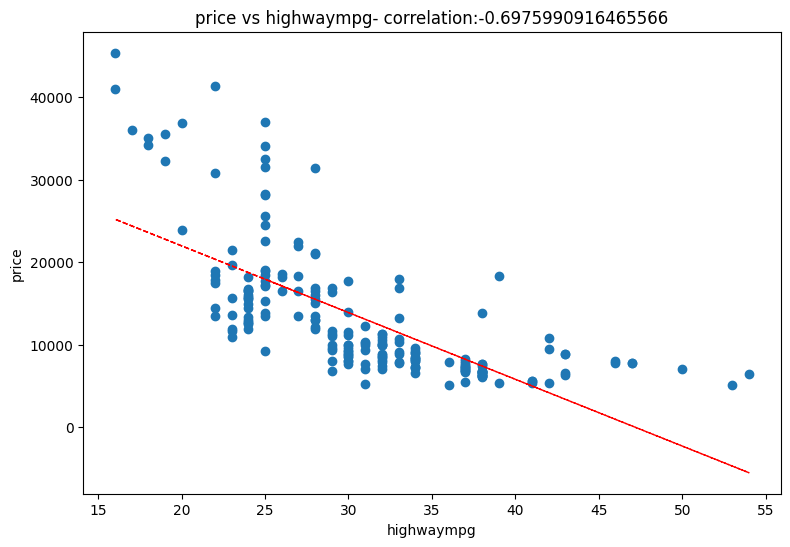

In [80]:
for col in numeric_features[1:-1]:
    fig = plt.figure(figsize=(9,6))
    ax = fig.gca()
    feature = dataset[col]
    label = dataset['price']
    correlation = feature.corr(label)
    plt.scatter(feature, label)
    plt.xlabel(feature.name)
    plt.ylabel('price')
    ax.set_title('price vs ' + feature.name + '- correlation:' + str(correlation))
    z= np.polyfit(dataset[feature.name], dataset['price'], 1)
    y_hat= np.poly1d(z)(dataset[feature.name])
    plt.plot(dataset[feature.name], y_hat, 'r--', lw=1)
    plt.show()



<Axes: >

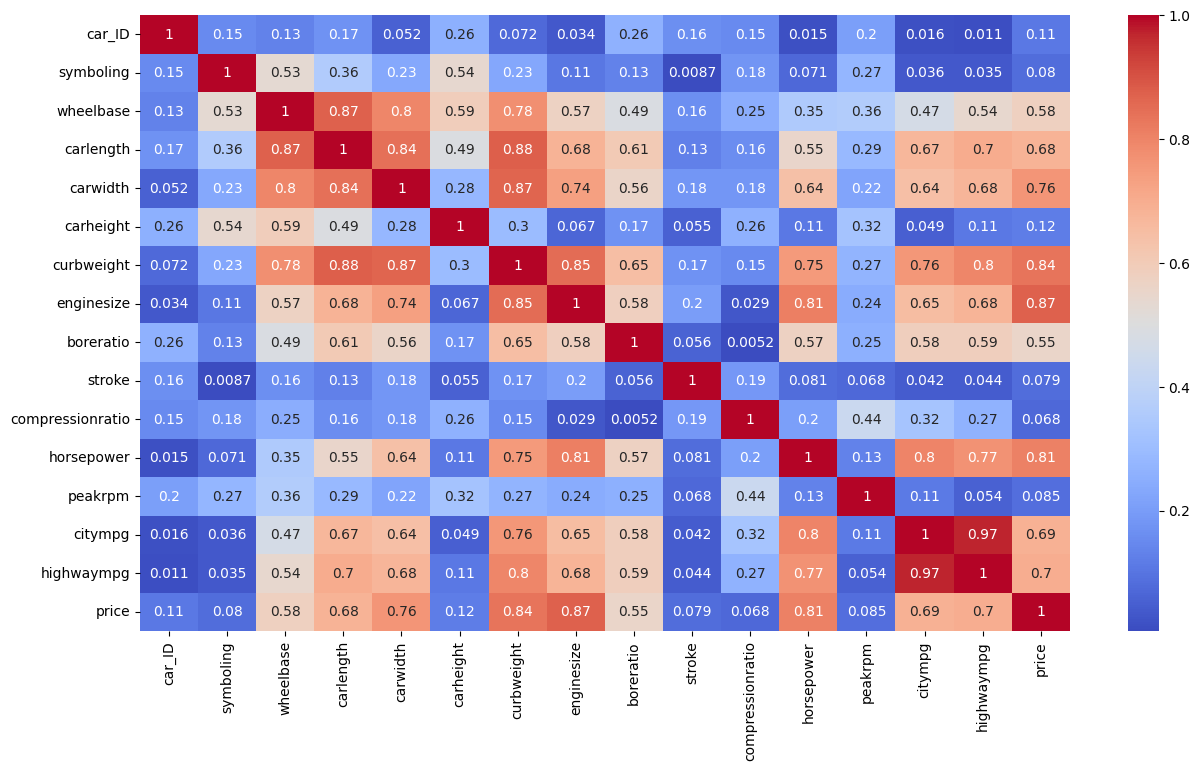

In [81]:
plt.figure(figsize=(15,8))
correlation = dataset.corr(numeric_only= True)
sns.heatmap(abs(correlation), annot= True, cmap='coolwarm')


# Balancing multicollearity data

In [82]:
dataset['mileage'] = 0.6*dataset['citympg'] + 0.4*dataset['highwaympg']
dataset['car_area']= dataset['carwidth']*dataset['carlength']

In [83]:
# calculating variance inflation factor (VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_vif(X):

    vif = pd.DataFrame()
    vif['variables'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [84]:
# calculating VIF except car_id and price

calc_vif(dataset[[i for i in dataset.describe().columns if i not in ['car_ID','price']]])

,variables,VIF
0,symboling,2.646796
1,wheelbase,2316.959780
2,carlength,6136.028870
3,carwidth,3170.397591
4,carheight,1108.503341
5,curbweight,415.172460
6,enginesize,68.941339
7,boreratio,326.471548
8,stroke,132.074737
9,compressionratio,16.465709


In [85]:
calc_vif(dataset[( i for i in dataset.describe().columns if i not in ['car_ID', 'prices','carlength','carwidth','citympg','highwaympg'])])

,variables,VIF
0,symboling,2.055846
1,wheelbase,1983.305426
2,carheight,827.157480
3,curbweight,407.540635
4,enginesize,89.528127
5,boreratio,268.807538
6,stroke,133.556552
7,compressionratio,17.122012
8,horsepower,60.717490
9,peakrpm,196.209448


In [86]:
# wheelbase and car_area is large , checking their collearity and other  as well and balancing



In [87]:
calc_vif(dataset[( i for i in dataset.describe().columns if i not in ['car_ID', 'price','carlength','carwidth','citympg','highwaympg','wheelbase','car_area','carheight','curbweight','boreratio','horsepower','stroke','peakrpm'])])

,variables,VIF
0,symboling,1.462763
1,enginesize,5.270022
2,compressionratio,9.391798
3,mileage,8.947241


In [88]:
numerical_features = ['symboling','enginesize','compressionratio','mileage']

In [89]:
dataset['CarName'].unique()

array(['alfa-romero giulia', 'alfa-romero stelvio',
       'alfa-romero Quadrifoglio', 'audi 100 ls', 'audi 100ls',
       'audi fox', 'audi 5000', 'audi 4000', 'audi 5000s (diesel)',
       'bmw 320i', 'bmw x1', 'bmw x3', 'bmw z4', 'bmw x4', 'bmw x5',
       'chevrolet impala', 'chevrolet monte carlo', 'chevrolet vega 2300',
       'dodge rampage', 'dodge challenger se', 'dodge d200',
       'dodge monaco (sw)', 'dodge colt hardtop', 'dodge colt (sw)',
       'dodge coronet custom', 'dodge dart custom',
       'dodge coronet custom (sw)', 'honda civic', 'honda civic cvcc',
       'honda accord cvcc', 'honda accord lx', 'honda civic 1500 gl',
       'honda accord', 'honda civic 1300', 'honda prelude',
       'honda civic (auto)', 'isuzu MU-X', 'isuzu D-Max ',
       'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf', 'jaguar xk',
       'maxda rx3', 'maxda glc deluxe', 'mazda rx2 coupe', 'mazda rx-4',
       'mazda glc deluxe', 'mazda 626', 'mazda glc', 'mazda rx-7 gs',
       'mazda glc 

# Merging same companies ie spelling errors

In [90]:
dataset['company']= dataset['CarName'].str.split(' ', expand= True)[0]
dataset['company']= dataset['company'].replace({'toyouta': 'Toyota', 'vw':'Volkswagen','vokswagen':'Volkswagen','maxda':'Mazda','porcshce':'Porsche'})

dataset['company']= dataset['company'].str.title()
dataset['company'].value_counts()

,count
company,
Toyota,32
Nissan,18
Mazda,17
Mitsubishi,13
Honda,13
Subaru,12
Volkswagen,12
Volvo,11
Peugeot,11


#plotting charts for categorical columns

In [91]:
categorical_features = dataset.describe(include= ['object','category']).columns


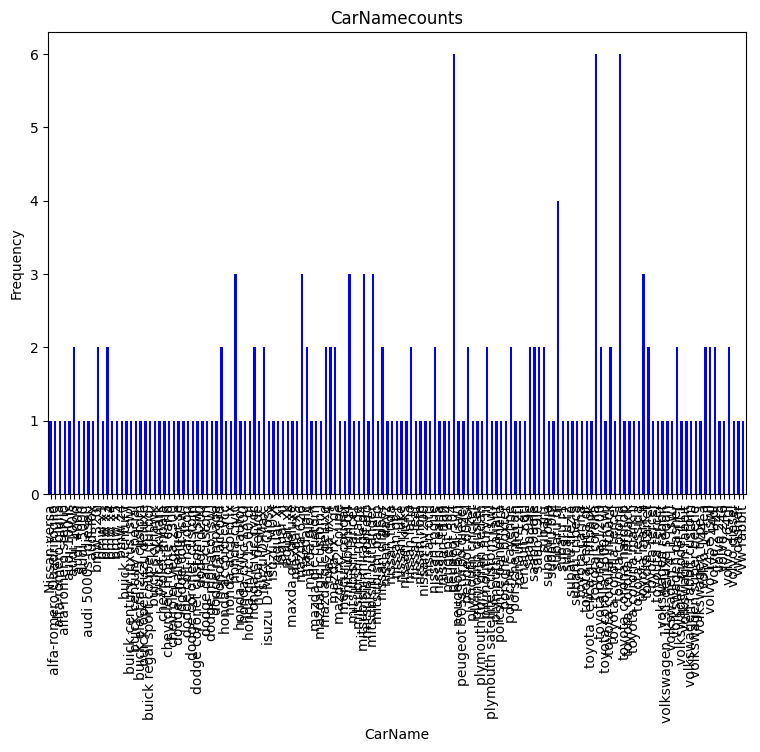

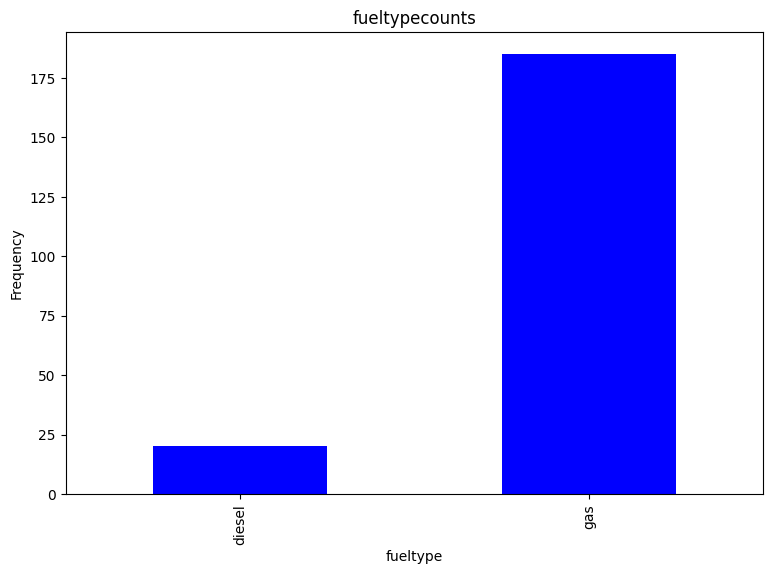

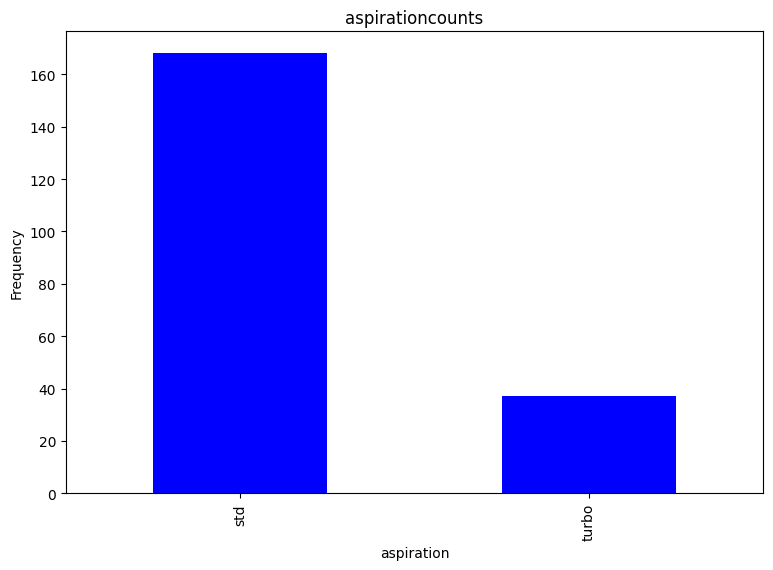

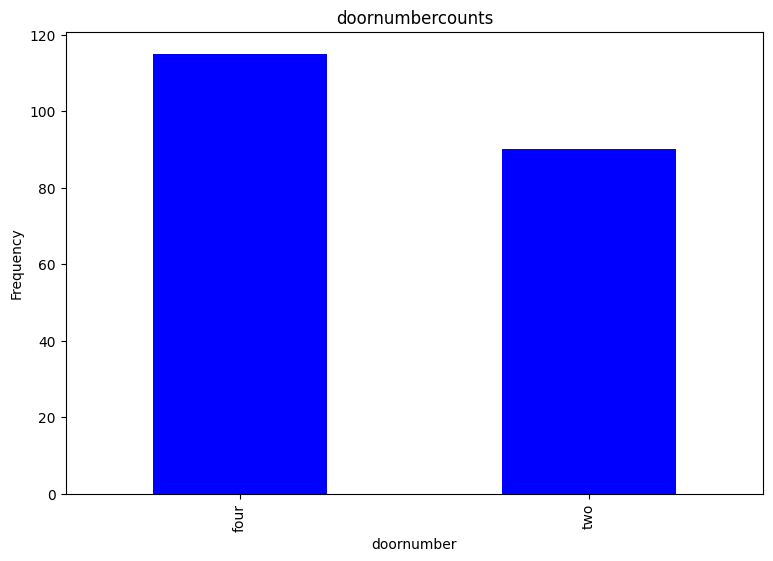

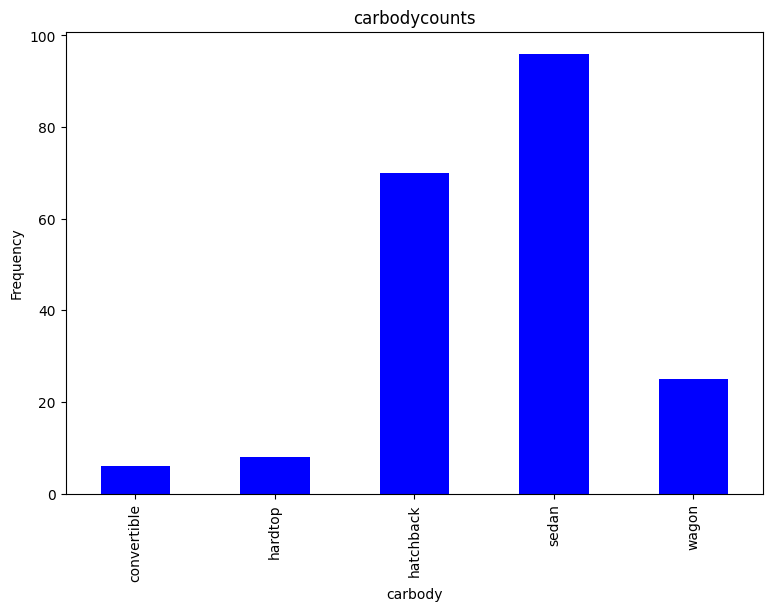

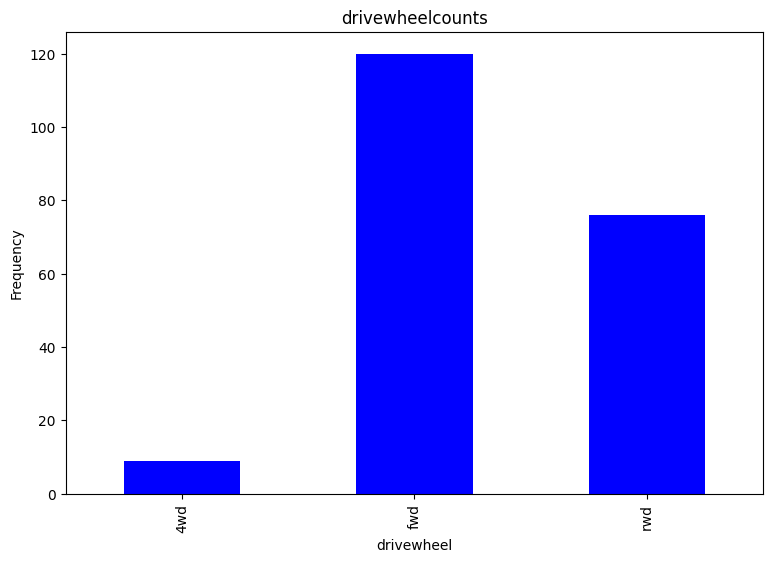

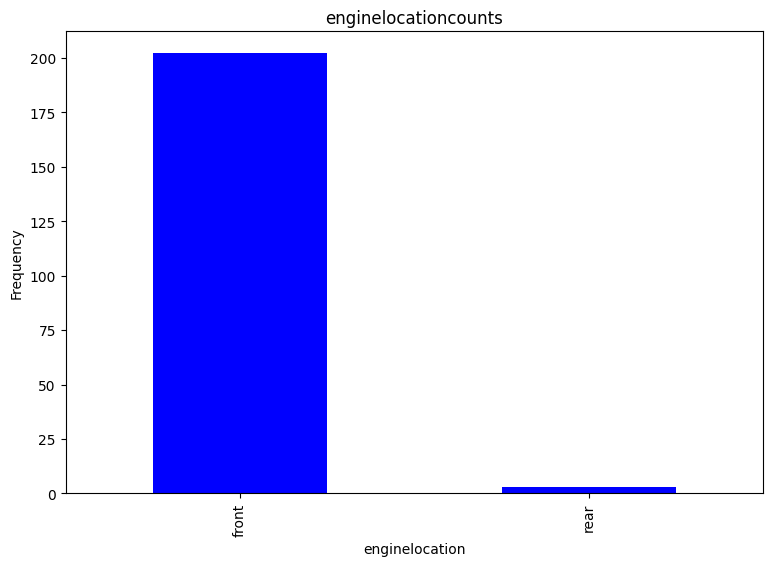

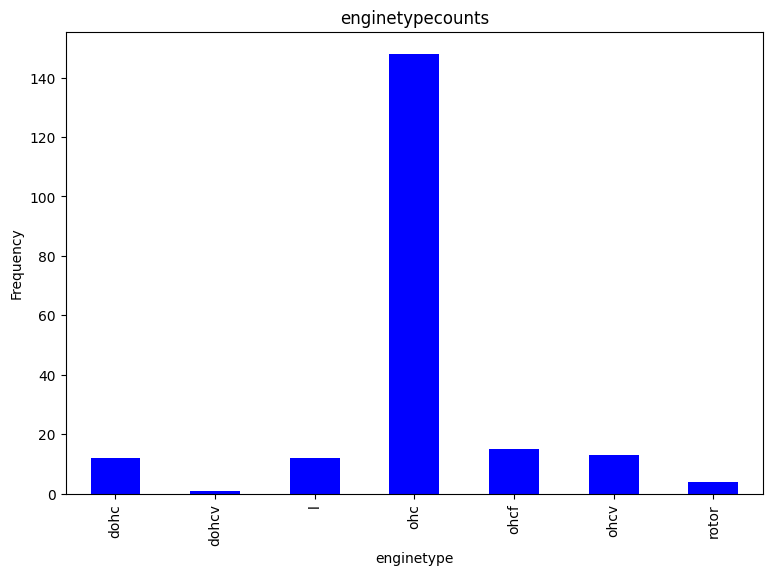

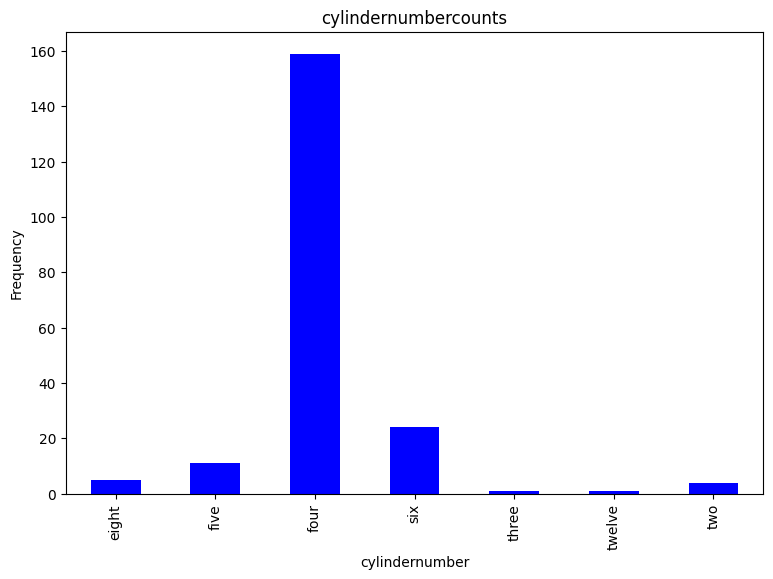

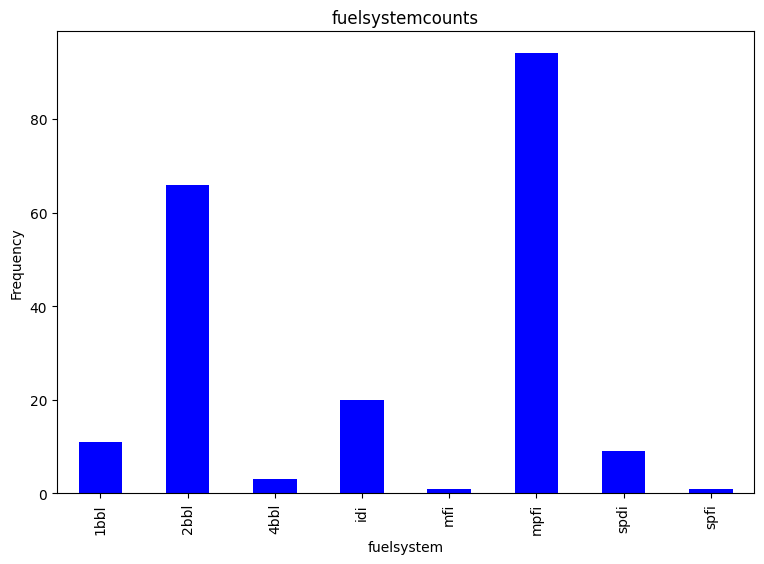

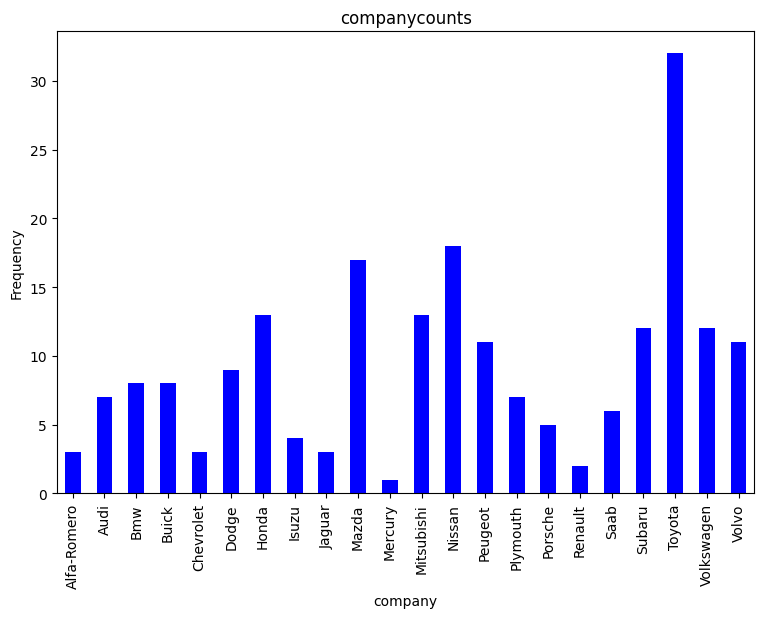

In [92]:
for col in categorical_features:
    counts = dataset[col].value_counts().sort_index()
    fig = plt.figure(figsize=(9,6))
    ax = fig.gca()
    counts.plot.bar(ax = ax, color = 'blue')
    ax.set_title(col + 'counts')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.show()

In [93]:
dataset['fueltype'].value_counts()


,count
fueltype,
gas,185
diesel,20


# plotting BoxPlot for price vs Each Categorical Feature

In [94]:
dataset['enginelocation'].value_counts()

,count
enginelocation,
front,202
rear,3


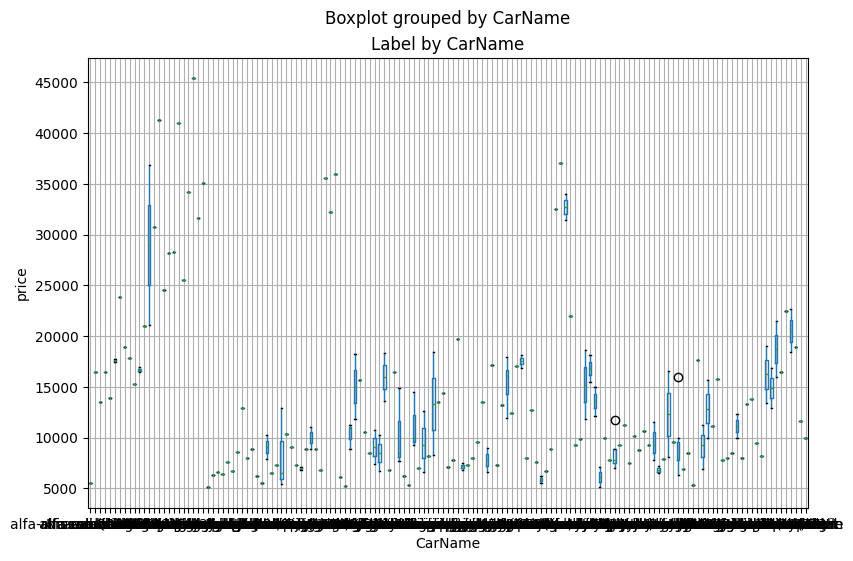

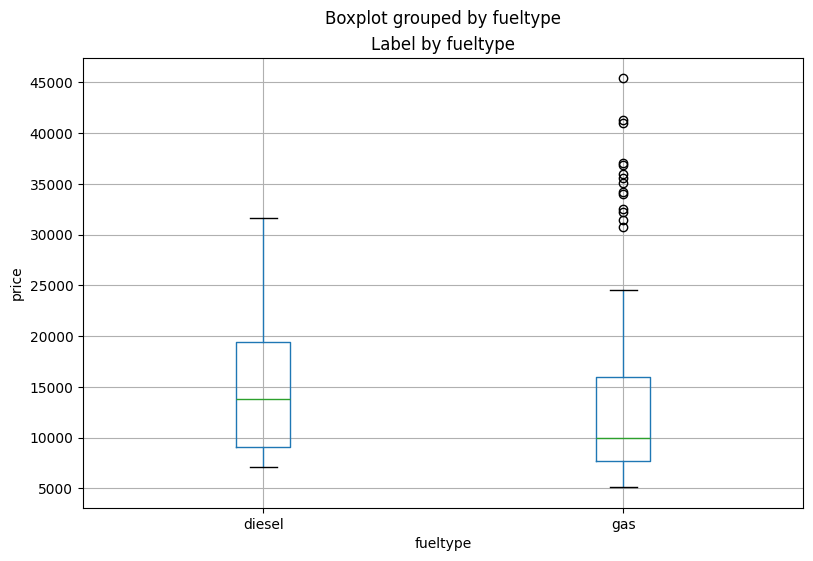

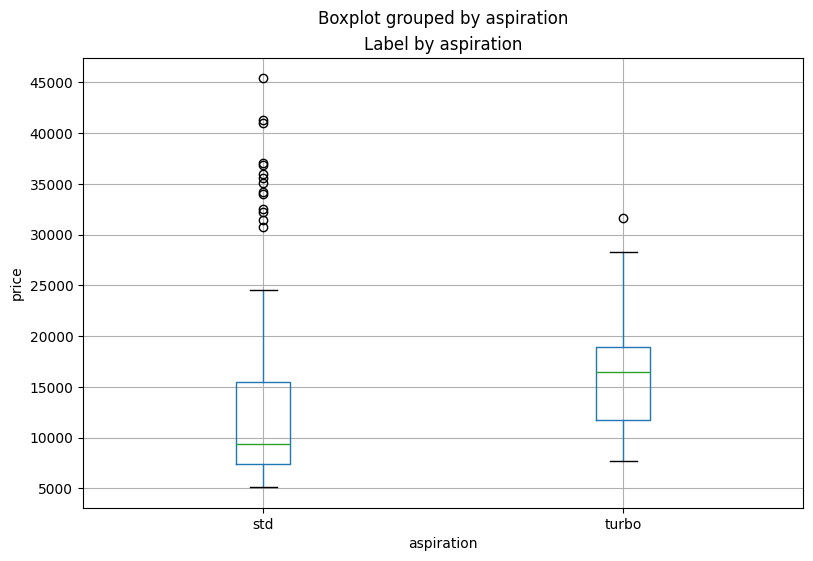

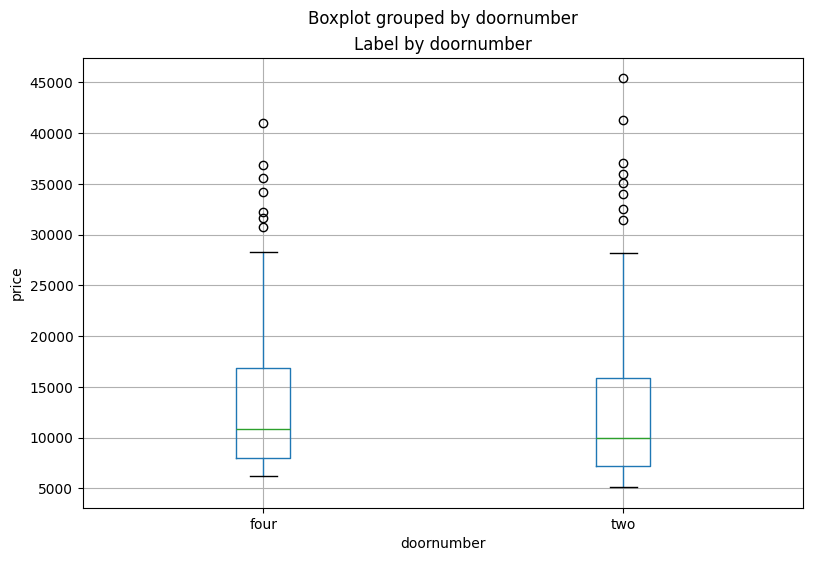

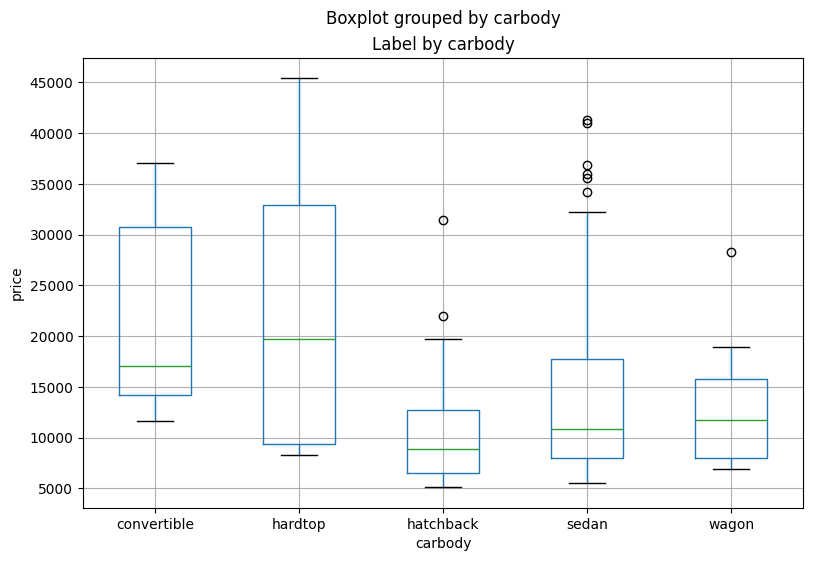

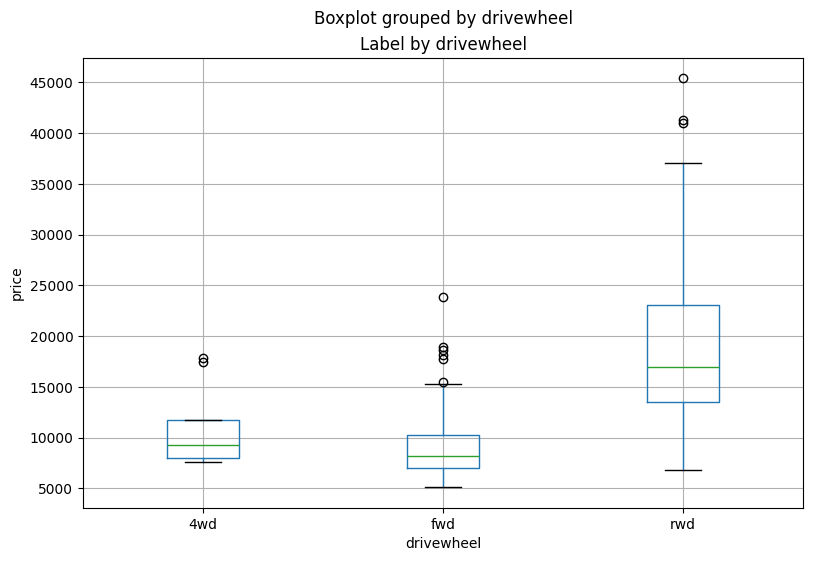

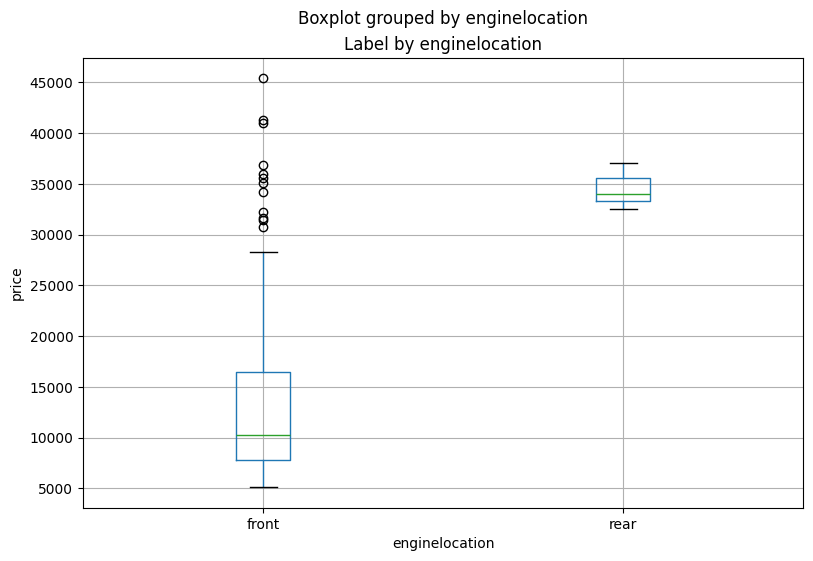

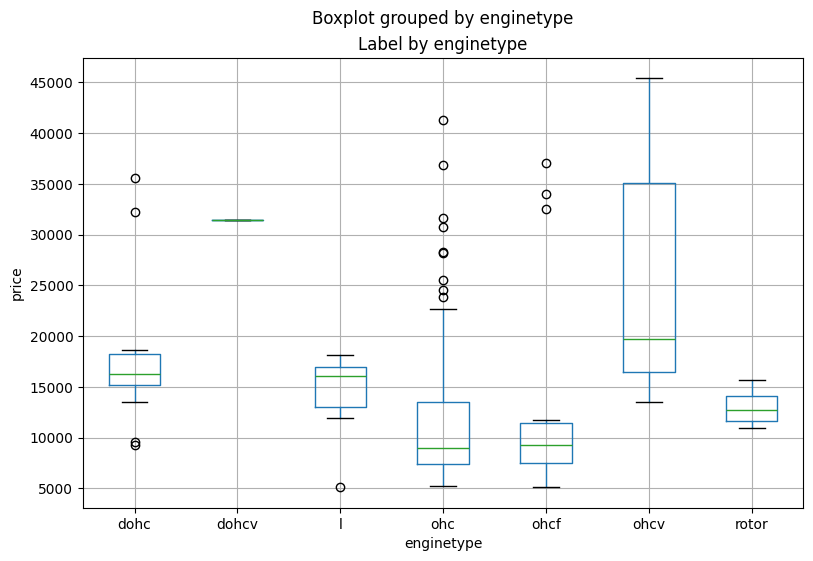

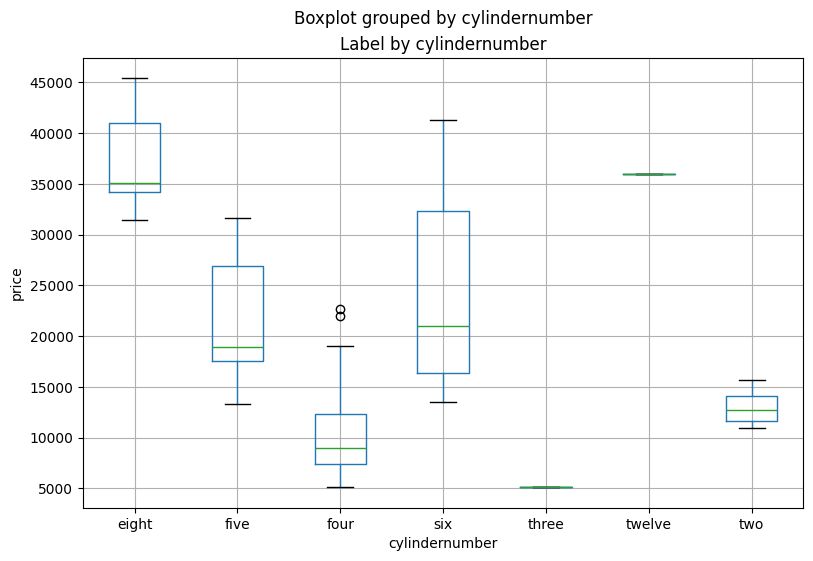

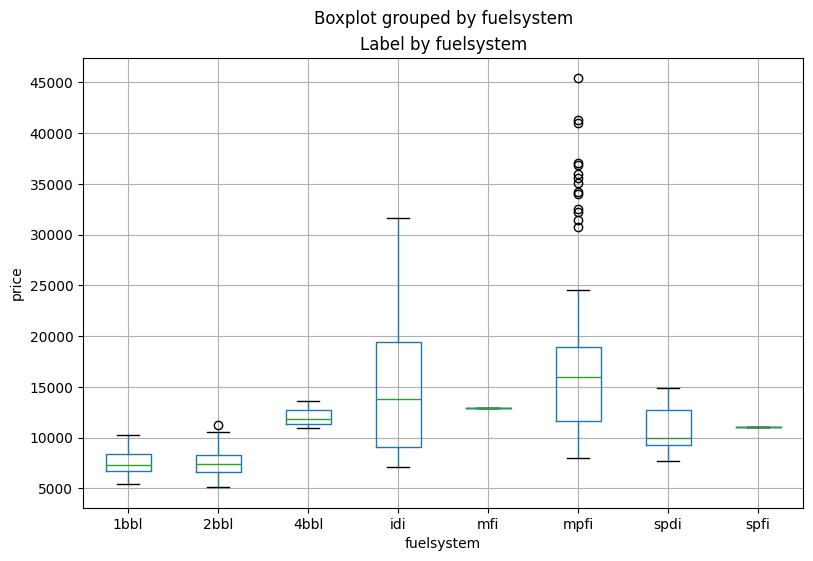

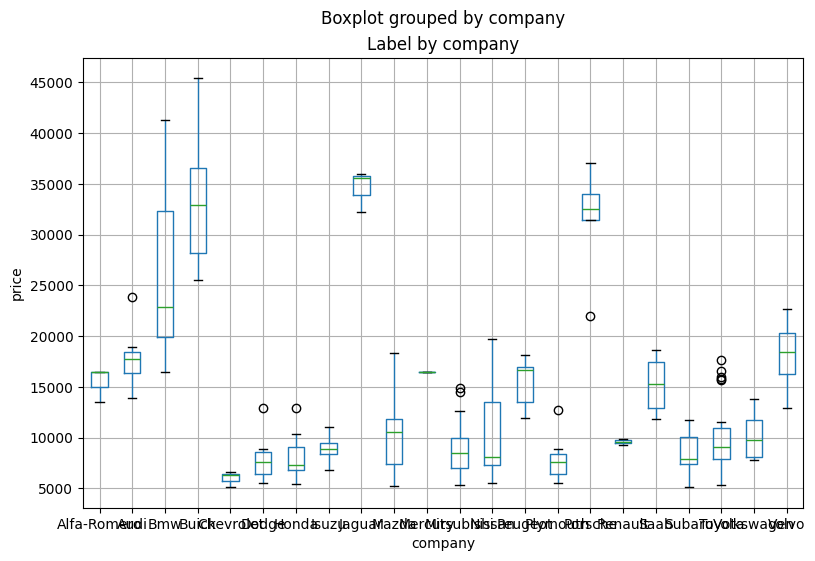

In [95]:
for col in categorical_features:
    fig = plt.figure(figsize=(9,6))
    ax = fig.gca()
    dataset.boxplot(column='price', by=col, ax=ax)
    ax.set_title('Label by ' + col)
    ax.set_ylabel('price')
plt.show()

<Figure size 1500x800 with 0 Axes>

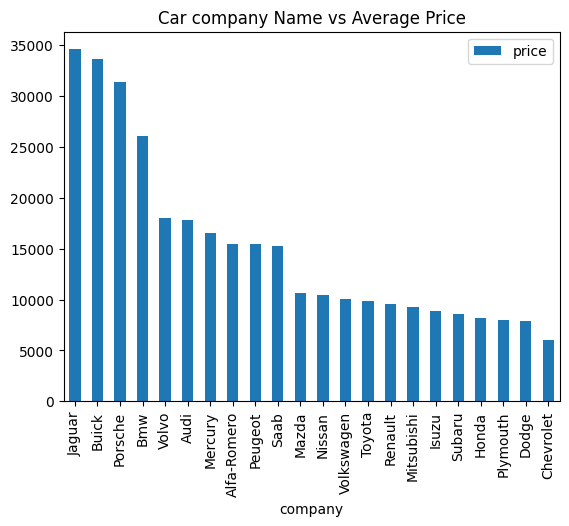

In [96]:
plt.figure(figsize=(15,8))

df_autox = pd.DataFrame(dataset.groupby(['company'])['price'].mean().sort_values(ascending=False))
df_autox.plot.bar()
plt.title('Car company Name vs Average Price')
plt.show()

In [97]:
df_autox.rename(columns={'price':'price_mean'},inplace=True)

In [98]:
#Merging Dataframes
dataset= dataset.merge(df_autox,on= 'company', how='left')


In [99]:
# Coverting avg price into 3 categories

dataset['company_cat']= dataset['price_mean'].apply(lambda x : 0 if x<12000 else (1 if 12000<= x<24000 else 2))


In [100]:
dataset.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,horsepower,peakrpm,citympg,highwaympg,price,mileage,car_area,company,price_mean,company_cat
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,13495.0,23.4,10820.08,Alfa-Romero,15498.333333,1
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,16500.0,23.4,10820.08,Alfa-Romero,15498.333333,1
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,154,5000,19,26,16500.0,21.8,11213.60,Alfa-Romero,15498.333333,1
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,102,5500,24,30,13950.0,26.4,11690.92,Audi,17859.166714,1
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,115,5500,18,22,17450.0,19.6,11726.24,Audi,17859.166714,1


In [101]:
correlation.price

,price
car_ID,-0.109093
symboling,-0.079978
wheelbase,0.577816
carlength,0.682920
carwidth,0.759325
carheight,0.119336
curbweight,0.835305
enginesize,0.874145
boreratio,0.553173
stroke,0.079443


In [102]:
dataset_pr = dataset.copy()

In [103]:
dataset.fuelsystem.value_counts()

,count
fuelsystem,
mpfi,94
2bbl,66
idi,20
1bbl,11
spdi,9
4bbl,3
mfi,1
spfi,1


In [104]:
# Data encoding
# Label encoding

encoders_nums = {'fueltype':{'diesel':1,'gas':0},
                 'aspiration':{'std':0,'turbo':1},
                 'doornumber':{'four':4,'two':2},
                 'drivewheel':{'rwd':1,'fwd':0,'4wd':0},
                 'cylindernumber':{'four':4,'six':6,'five':5,'three':3,'twelve':12,'two':2,'eight':8}}

dataset_pr = dataset_pr.replace(encoders_nums)


In [105]:
# Categories to columns/ presence encoding

dataset_pr = pd.get_dummies(dataset_pr, columns=['carbody','enginetype','fuelsystem'], prefix=['body','etype','fsystem'])

In [106]:
dataset_pr.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,...,etype_ohcv,etype_rotor,fsystem_1bbl,fsystem_2bbl,fsystem_4bbl,fsystem_idi,fsystem_mfi,fsystem_mpfi,fsystem_spdi,fsystem_spfi
0,1,3,alfa-romero giulia,0,0,2,1,front,88.6,168.8,...,False,False,False,False,False,False,False,True,False,False
1,2,3,alfa-romero stelvio,0,0,2,1,front,88.6,168.8,...,False,False,False,False,False,False,False,True,False,False
2,3,1,alfa-romero Quadrifoglio,0,0,2,1,front,94.5,171.2,...,True,False,False,False,False,False,False,True,False,False
3,4,2,audi 100 ls,0,0,4,0,front,99.8,176.6,...,False,False,False,False,False,False,False,True,False,False
4,5,2,audi 100ls,0,0,4,0,front,99.4,176.6,...,False,False,False,False,False,False,False,True,False,False


In [107]:
# Joining numerical and categorical features

features= numerical_features.copy()
features.extend(['fueltype','aspiration','doornumber','drivewheel','company_cat','body_convertible','body_hardtop','body_hatchback','body_sedan','body_wagon','etype_dohc','etype_l','etype_ohc','etype_ohcf','etype_ohcv','fsystem_1bbl','fsystem_2bbl','fsystem_idi','fsystem_mpfi','fsystem_spdi'])

In [108]:
features

['symboling',
 'enginesize',
 'compressionratio',
 'mileage',
 'fueltype',
 'aspiration',
 'doornumber',
 'drivewheel',
 'company_cat',
 'body_convertible',
 'body_hardtop',
 'body_hatchback',
 'body_sedan',
 'body_wagon',
 'etype_dohc',
 'etype_l',
 'etype_ohc',
 'etype_ohcf',
 'etype_ohcv',
 'fsystem_1bbl',
 'fsystem_2bbl',
 'fsystem_idi',
 'fsystem_mpfi',
 'fsystem_spdi']

In [109]:
# using zscore(to convert all values into same scale) + train test split

from scipy.stats import zscore
#train test split
x= dataset_pr[features].apply(zscore)
y= np.log(dataset_pr['price'])

In [110]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state= 0)
print(x_train.shape)
print(x_test.shape)

(164, 24)
(41, 24)


In [111]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(x_train, y_train)
reg.score(x_train, y_train)


0.9329455273978196

In [112]:
reg.coef_

array([ 0.01754052,  0.17810264,  0.03159813, -0.1289689 ,  0.00859628,
        0.05000998,  0.04477757,  0.03574356,  0.14908464,  0.02955297,
       -0.00113656, -0.00043262,  0.00168313, -0.01648996, -0.09200619,
       -0.11560026, -0.14243831, -0.07943619, -0.09771072,  0.00393895,
       -0.03241724,  0.00859628,  0.04824621, -0.01634261])

In [113]:
y_pred = reg.predict(x_test)

In [114]:
from sklearn.metrics import mean_squared_error

MSE = mean_squared_error(np.exp(y_test), np.exp(y_pred))
RMSE = np.sqrt(MSE)
print("MSE:",MSE)
print("RMSE:", RMSE)

MSE: 8915658.554040462
RMSE: 2985.9100043438116


In [115]:
from sklearn.metrics import r2_score
r2 = r2_score(np.exp(y_test), np.exp(y_pred))
print("R2:", r2)
print("Adjusted R2 :",1-(1-r2_score(10**(y_test), 10**(y_pred)))*((x_test.shape[0]-1)/(x_test.shape[0]-x_test.shape[1]-1)))

R2: 0.8848349527311523
Adjusted R2 : 0.5306456583628065


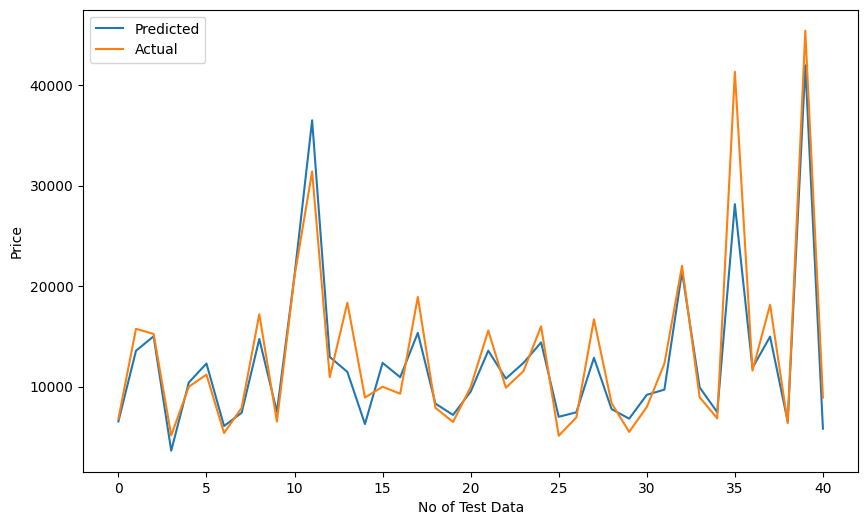

In [116]:
plt.figure(figsize=(10,6))
plt.plot(np.exp(y_pred))
plt.plot(np.array(np.exp(y_test)))
plt.legend(['Predicted','Actual'])
plt.xlabel('No of Test Data')
plt.ylabel('Price')
plt.show()

# lasso regression

In [117]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error

lasso = Lasso(alpha=0.01)
lasso.fit(x_train, y_train)

y_pred_lasso = lasso.predict(x_test)

MSE_lasso = mean_squared_error(np.exp(y_test), np.exp(y_pred_lasso))
RMSE_lasso = np.sqrt(MSE_lasso)
r2_lasso = r2_score(np.exp(y_test), np.exp(y_pred_lasso))
adj_r2_lasso = 1 - (1 - r2_lasso) * ((x_test.shape[0]-1) / (x_test.shape[0]-x_test.shape[1]-1))

print("Lasso Regression")
print(f"  RMSE        : {RMSE_lasso:.2f}")
print(f"  R²          : {r2_lasso:.4f}")
print(f"  Adjusted R² : {adj_r2_lasso:.4f}")

Lasso Regression
  RMSE        : 2890.96
  R²          : 0.8920
  Adjusted R² : 0.7301


#Ridge Regression

In [118]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

y_pred_ridge = ridge.predict(x_test)

MSE_ridge = mean_squared_error(np.exp(y_test), np.exp(y_pred_ridge))
RMSE_ridge = np.sqrt(MSE_ridge)
r2_ridge = r2_score(np.exp(y_test), np.exp(y_pred_ridge))
adj_r2_ridge = 1 - (1 - r2_ridge) * ((x_test.shape[0]-1) / (x_test.shape[0]-x_test.shape[1]-1))

print("Ridge Regression")
print(f"  RMSE        : {RMSE_ridge:.2f}")
print(f"  R²          : {r2_ridge:.4f}")
print(f"  Adjusted R² : {adj_r2_ridge:.4f}")

Ridge Regression
  RMSE        : 2911.22
  R²          : 0.8905
  Adjusted R² : 0.7263


#Model Comparision

In [119]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso', 'Ridge'],
    'R²': [r2_score(np.exp(y_test), np.exp(y_pred)),
            r2_lasso, r2_ridge],
    'RMSE': [np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred))),
              RMSE_lasso, RMSE_ridge]
})
print(results.sort_values('R²', ascending=False))

               Model        R²         RMSE
1              Lasso  0.892043  2890.955079
2              Ridge  0.890524  2911.219327
0  Linear Regression  0.884835  2985.910004


#Feature importance (lasso coefficients)

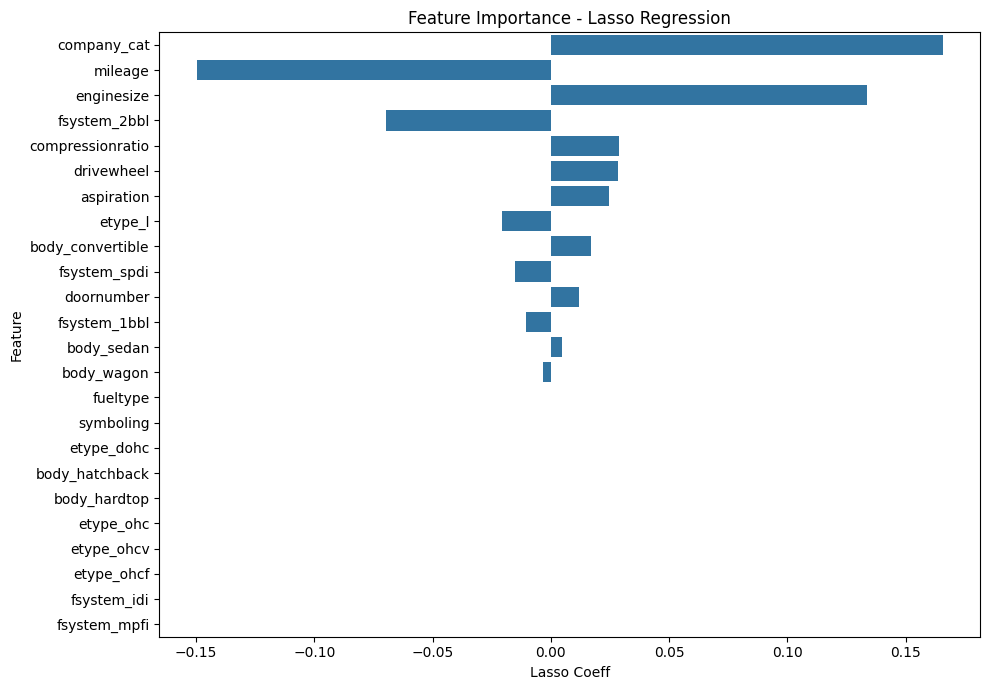

In [120]:
coeff_df = pd.DataFrame({
    'Feature': features,
    'Lasso Coeff': lasso.coef_
}).sort_values('Lasso Coeff', key=abs, ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(data=coeff_df, x='Lasso Coeff', y='Feature')
plt.title('Feature Importance - Lasso Regression')
plt.tight_layout()
plt.show()

# Conclusion

## Business Questions Answered

### 1. Which variables are significant in predicting car price?

Based on the Lasso Regression feature importance analysis, the most significant variables are:

- **Company Category (brand reputation)** — The single biggest driver of price. Premium brands command significantly higher prices in the US market.
- **Engine Size** — Larger engines strongly correlate with higher prices.
- **Mileage (fuel efficiency)** — Higher mileage cars tend to be in the budget segment, negatively impacting price.
- **Fuel System (2bbl)** — Associated with lower-priced cars.
- **Aspiration & Drivewheel** — Moderate positive influence on price.

Several variables like `fueltype`, `symboling`, `body_hatchback`, and `fsystem_mpfi` were eliminated by Lasso as insignificant.

### 2. How well do these variables describe car price?

| Model | R² Score | RMSE |
|-------|----------|------|
| Lasso Regression | 0.8920 | 2890.95 |
| Ridge Regression | 0.8905 | 2911.22 |
| Linear Regression | 0.8848 | 2985.91 |

**Lasso Regression** performed best with an R² of **0.89**, meaning the selected variables explain **89% of the variation in car prices** in the US market.

## Recommendations for Geely Auto

- Focus on **engine size** as a key design parameter — larger engines justify higher pricing.
- **Brand positioning** is critical — investing in brand reputation will have the highest impact on achievable price points.
- Target the **mid-to-premium segment** (company_cat = 1 or 2) for competitive pricing against US and European brands.
- **Fuel efficiency** should be balanced carefully — highly fuel-efficient cars are perceived as budget vehicles in the US market.